# 11 Comparative Model Interpretation



## 11.0 Purpose and scope

This notebook interprets the final evaluated models from Stage 9 and Stage 10. The purpose is to understand what the selected models learned and whether the flexible Random Forest models add explanatory or targeting value beyond the transparent Logistic Regression benchmark.

Stage 11 does not perform model selection. The final models, feature sets, hyperparameters, preprocessing rules, and chronological test split were already fixed before final test evaluation. Therefore, this notebook does not retrain models, retune hyperparameters, change feature sets, or select a new winner.

The interpretation focuses on the final C-expanded models:

- Open prediction:
  - Logistic Regression C-expanded
  - Random Forest C-expanded

- Click prediction:
  - Logistic Regression C-expanded
  - Random Forest C-expanded

The open Decision Tree C-expanded model may be referenced as a simple nonlinear benchmark if useful, but it is not the main focus of the comparative interpretation.

The main interpretation questions are:

1. What features does Logistic Regression associate with higher or lower predicted engagement?
2. What features does Random Forest rely on most when predicting engagement?
3. Are the main model drivers consistent across Logistic Regression and Random Forest?
4. Does Random Forest reveal nonlinear, threshold-like, or segment-specific patterns that Logistic Regression cannot capture directly?
5. Can model interpretation help explain why Random Forest performs better in narrow click top-k targeting, even though Logistic Regression performs slightly better on aggregate click PR-AUC and probability quality?

All interpretation is model-based. The results describe how the trained models behave; they do not establish causal effects on user engagement.

## 11.1 Load and verify final artifacts

This section loads the fixed artifacts needed for interpretation:

- Stage 9 refitted model pipelines;
- Stage 9 metadata and fitted transformed feature names;
- Stage 10 final-test metrics and predictions;
- Stage 10 top-k/lift results for click.

The purpose is to verify that Stage 11 is interpreting the same models that were evaluated in Stage 10.

In [1]:
# imports
from pathlib import Path
import json
import joblib

import numpy as np
import pandas as pd

RANDOM_STATE = 42

PROJECT_ROOT = Path.home() / "Documents" / "Thesis"

DATA_DIR = PROJECT_ROOT / "Data"
PROCESSED_DATA_DIR = DATA_DIR / "Processed Data"

OUTPUT_DIR = PROJECT_ROOT / "Outputs"
FINAL_EVAL_DIR = OUTPUT_DIR / "10_final_evaluation"

print("Project root:", PROJECT_ROOT)
print("Output dir exists:", OUTPUT_DIR.exists())
print("Final evaluation dir exists:", FINAL_EVAL_DIR.exists())

Project root: /Users/khanhhien/Documents/Thesis
Output dir exists: True
Final evaluation dir exists: True


In [2]:
# paths

# stage 9 artifacts
REFIT_METADATA_PATH = OUTPUT_DIR / "9_refit_metadata_v1.json"
FITTED_FEATURE_NAMES_PATH = OUTPUT_DIR / "9_refit_fitted_feature_names_v1.json"
REFIT_SUMMARY_PATH = OUTPUT_DIR / "9_refit_summary_v1.csv"

# stage 10 outputs
OPEN_METRICS_PATH = FINAL_EVAL_DIR / "10_open_final_test_metrics_v1.csv"
CLICK_METRICS_PATH = FINAL_EVAL_DIR / "10_click_final_test_metrics_v1.csv"
OPEN_PREDICTIONS_PATH = FINAL_EVAL_DIR / "10_open_final_test_predictions_v1.csv"
CLICK_PREDICTIONS_PATH = FINAL_EVAL_DIR / "10_click_final_test_predictions_v1.csv"
CLICK_TOPK_PATH = FINAL_EVAL_DIR / "10_click_topk_lift_v1.csv"
CV_TEST_COMPARISON_PATH = FINAL_EVAL_DIR / "10_cv_vs_test_comparison_v1.csv"

required_paths = [
    REFIT_METADATA_PATH,
    FITTED_FEATURE_NAMES_PATH,
    REFIT_SUMMARY_PATH,
    OPEN_METRICS_PATH,
    CLICK_METRICS_PATH,
    OPEN_PREDICTIONS_PATH,
    CLICK_PREDICTIONS_PATH,
    CLICK_TOPK_PATH,
    CV_TEST_COMPARISON_PATH,
]

for path in required_paths:
    print(path.name, "exists:", path.exists())

9_refit_metadata_v1.json exists: True
9_refit_fitted_feature_names_v1.json exists: True
9_refit_summary_v1.csv exists: True
10_open_final_test_metrics_v1.csv exists: True
10_click_final_test_metrics_v1.csv exists: True
10_open_final_test_predictions_v1.csv exists: True
10_click_final_test_predictions_v1.csv exists: True
10_click_topk_lift_v1.csv exists: True
10_cv_vs_test_comparison_v1.csv exists: True


In [3]:
with open(REFIT_METADATA_PATH, "r") as f:
    refit_metadata = json.load(f)

with open(FITTED_FEATURE_NAMES_PATH, "r") as f:
    fitted_feature_names = json.load(f)

refit_summary = pd.read_csv(REFIT_SUMMARY_PATH)

open_metrics = pd.read_csv(OPEN_METRICS_PATH)
click_metrics = pd.read_csv(CLICK_METRICS_PATH)

open_predictions = pd.read_csv(OPEN_PREDICTIONS_PATH)
click_predictions = pd.read_csv(CLICK_PREDICTIONS_PATH)

click_topk = pd.read_csv(CLICK_TOPK_PATH)
cv_vs_test = pd.read_csv(CV_TEST_COMPARISON_PATH)

print("Loaded artifacts successfully.")
print("Refit summary shape:", refit_summary.shape)
print("Open predictions shape:", open_predictions.shape)
print("Click predictions shape:", click_predictions.shape)

Loaded artifacts successfully.
Refit summary shape: (5, 20)
Open predictions shape: (275718, 9)
Click predictions shape: (289973, 17)


In [4]:
# load only models needed for core interpretation
model_paths = {
    key: Path(path)
    for key, path in refit_metadata["model_paths"].items()
}

core_model_keys = [
    "open__logistic_regression__C_expanded",
    "open__random_forest__C_expanded",
    "click__logistic_regression__C_expanded",
    "click__random_forest__C_expanded",
]

models = {}

for key in core_model_keys:
    model_path = model_paths[key]
    print(key, "->", model_path.name, "exists:", model_path.exists())
    models[key] = joblib.load(model_path)

print("Core models loaded:", list(models.keys()))

open__logistic_regression__C_expanded -> 9_open_refit_model_logistic_C_v1.joblib exists: True
open__random_forest__C_expanded -> 9_open_refit_model_random_forest_C_v1.joblib exists: True
click__logistic_regression__C_expanded -> 9_click_refit_model_logistic_C_v1.joblib exists: True
click__random_forest__C_expanded -> 9_click_refit_model_random_forest_C_v1.joblib exists: True
Core models loaded: ['open__logistic_regression__C_expanded', 'open__random_forest__C_expanded', 'click__logistic_regression__C_expanded', 'click__random_forest__C_expanded']


In [5]:
# verify postive class
for key, pipeline in models.items():
    estimator = pipeline.named_steps["model"]
    classes = estimator.classes_.tolist()
    pos_idx = classes.index(1.0)
    
    print(
        key,
        "| classes:", classes,
        "| positive class index:", pos_idx
    )

open__logistic_regression__C_expanded | classes: [0.0, 1.0] | positive class index: 1
open__random_forest__C_expanded | classes: [0.0, 1.0] | positive class index: 1
click__logistic_regression__C_expanded | classes: [0.0, 1.0] | positive class index: 1
click__random_forest__C_expanded | classes: [0.0, 1.0] | positive class index: 1


## 11.2 Prepare interpretation datasets

The interpretation analyses in Stage 11 are based on the same chronological final-test setting used in Stage 10.

The purpose of this section is to recreate the final test datasets corresponding to the evaluated future-campaign holdout period. These datasets will be used for feature-importance analysis, effect-shape analysis, and top-k segment interpretation.

No model fitting occurs in this section. The goal is only to reconstruct the final evaluation data used by the already-fitted Stage 9 pipelines.

In [6]:
# reload processed datasets
df_open = pd.read_parquet(
    PROCESSED_DATA_DIR / "df_open_model_v1.parquet"
)

df_click = pd.read_parquet(
    PROCESSED_DATA_DIR / "df_click_model_v1.parquet"
)

print(df_open.shape)
print(df_click.shape)

(1057544, 38)
(1104242, 38)


In [7]:
# recreate chronological split
GROUP_COL = "mailing_id"

open_campaigns = np.sort(df_open[GROUP_COL].unique())
click_campaigns = np.sort(df_click[GROUP_COL].unique())

open_split_idx = int(len(open_campaigns) * 0.80)
click_split_idx = int(len(click_campaigns) * 0.80)

open_test_campaigns = open_campaigns[open_split_idx:]
click_test_campaigns = click_campaigns[click_split_idx:]

In [8]:
open_test_mask = df_open[GROUP_COL].isin(open_test_campaigns)
click_test_mask = df_click[GROUP_COL].isin(click_test_campaigns)

df_open_test = df_open.loc[open_test_mask].copy()
df_click_test = df_click.loc[click_test_mask].copy()

In [9]:
# verify stage 10 consistency
print("Open test rows:", len(df_open_test))
print("Click test rows:", len(df_click_test))

print("Open positive rate:",
      df_open_test["open"].mean())

print("Click positive rate:",
      df_click_test["click"].mean())

Open test rows: 275718
Click test rows: 289973
Open positive rate: 0.4309983388824814
Click positive rate: 0.0006724764029754494


In [10]:
# define C_expanded feature lists

feature_types_C = {
    "numeric": [
        "age_clean",
        "n_interests",
        "subject_length",
        "preheader_length",
        "prior_email_count",
        "prior_open_count",
        "prior_click_count",
        "historical_open_rate",
        "historical_click_rate",
    ],
    
    "categorical": [
        "gender",
        "age_group",
        "campaign_topic",
        "subject_length_group",
        "preheader_length_group",
        "historical_open_bucket",
        "prior_email_frequency_bucket",
    ],
    
    "binary": [
        "interest_topic_match",
        "has_campaign_metadata",
        "subject_missing",
        "subject_contains_number",
        "subject_contains_promotion",
        "subject_contains_exclamation",
        "preheader_missing",
        "preheader_contains_number",
        "preheader_contains_promotion",
        "preheader_contains_exclamation",
        "had_prior_click",
        "is_first_email",
    ],
}

C_EXPANDED_FEATURES = (
    feature_types_C["numeric"]
    + feature_types_C["categorical"]
    + feature_types_C["binary"]
)

print("Number of raw features:", len(C_EXPANDED_FEATURES))
print(C_EXPANDED_FEATURES)

Number of raw features: 28
['age_clean', 'n_interests', 'subject_length', 'preheader_length', 'prior_email_count', 'prior_open_count', 'prior_click_count', 'historical_open_rate', 'historical_click_rate', 'gender', 'age_group', 'campaign_topic', 'subject_length_group', 'preheader_length_group', 'historical_open_bucket', 'prior_email_frequency_bucket', 'interest_topic_match', 'has_campaign_metadata', 'subject_missing', 'subject_contains_number', 'subject_contains_promotion', 'subject_contains_exclamation', 'preheader_missing', 'preheader_contains_number', 'preheader_contains_promotion', 'preheader_contains_exclamation', 'had_prior_click', 'is_first_email']


In [11]:
# build X/y datasets
OPEN_TARGET = "open"
CLICK_TARGET = "click"

X_open_test = df_open_test[C_EXPANDED_FEATURES].copy()
y_open_test = df_open_test[OPEN_TARGET].copy()

X_click_test = df_click_test[C_EXPANDED_FEATURES].copy()
y_click_test = df_click_test[CLICK_TARGET].copy()

In [12]:
# verify
print("Open test feature matrix:", X_open_test.shape)
print("Open target:", y_open_test.shape)

print("Click test feature matrix:", X_click_test.shape)
print("Click target:", y_click_test.shape)

print("Open positives:",
      y_open_test.sum())

print("Click positives:",
      y_click_test.sum())

Open test feature matrix: (275718, 28)
Open target: (275718,)
Click test feature matrix: (289973, 28)
Click target: (289973,)
Open positives: 118834.0
Click positives: 195.0


### Feature interpretation framework

To support model interpretation, the C-expanded features are grouped into conceptual categories that reflect their role in the email engagement process.

These groups are defined before interpretation and are used consistently throughout Stage 11 for Logistic Regression interpretation, Random Forest feature reliance analysis, and model-driver comparison.

The feature groups are:

- Historical Behaviour
- Campaign and Content
- Recipient Characteristics
- Engineered / Bucket / Interaction Features

These groups are used only as an interpretation framework and do not affect model training or prediction.

In [13]:
FEATURE_GROUPS = {

    "historical_behaviour": [
        "prior_email_count",
        "prior_open_count",
        "prior_click_count",
        "historical_open_rate",
        "historical_click_rate",
        "had_prior_click",
        "is_first_email",
    ],

    "campaign_content": [
        "campaign_topic",
        "interest_topic_match",

        "subject_length",
        "subject_length_group",
        "subject_missing",
        "subject_contains_number",
        "subject_contains_promotion",
        "subject_contains_exclamation",

        "preheader_length",
        "preheader_length_group",
        "preheader_missing",
        "preheader_contains_number",
        "preheader_contains_promotion",
        "preheader_contains_exclamation",

        "has_campaign_metadata",
    ],

    "recipient_characteristics": [
        "gender",
        "age_clean",
        "age_group",
        "n_interests",
    ],

    "engineered_bucket_interaction": [
        "historical_open_bucket",
        "prior_email_frequency_bucket",
    ]
}

## 11.3 Logistic Regression Interpretation

This section interprets the two final Logistic Regression C-expanded models as transparent benchmarks for open and click prediction.

The goal is to identify the strongest positive and negative coefficient patterns and then summarise them by conceptual feature group. Coefficients are interpreted as model associations, not causal effects.

Open:
- Which factors are associated with higher predicted opens?
- Which factors are associated with lower predicted opens?
- Are historical behaviour features dominant?
- Do campaign/content features still matter?

Click:
- Which factors are associated with higher predicted clicks?
- Which factors are associated with lower predicted clicks?
- How important is prior engagement history?
- Are content variables visible at all?

### 11.3.1 Extract transformed feature names

In [ ]:
OPEN_LR_KEY = "open__logistic_regression__C_expanded"
CLICK_LR_KEY = "click__logistic_regression__C_expanded"

open_lr_features = fitted_feature_names[OPEN_LR_KEY]
click_lr_features = fitted_feature_names[CLICK_LR_KEY]

print("Open LR transformed features:", len(open_lr_features))
print("Click LR transformed features:", len(click_lr_features))

print(open_lr_features[:10])

Open LR transformed features: 60
Click LR transformed features: 60
['numeric__age_clean', 'numeric__n_interests', 'numeric__subject_length', 'numeric__preheader_length', 'numeric__prior_email_count', 'numeric__prior_open_count', 'numeric__prior_click_count', 'numeric__historical_open_rate', 'numeric__historical_click_rate', 'categorical__gender_female']


### 11.3.2 Extract coefficients

In [ ]:
# extract coefficients function
def extract_logistic_coefficients(model_key, models, fitted_feature_names):
    pipeline = models[model_key]
    estimator = pipeline.named_steps["model"]
    
    feature_names = fitted_feature_names[model_key]
    coefficients = estimator.coef_.ravel()
    
    if len(feature_names) != len(coefficients):
        raise ValueError(
            f"Feature/coefficient length mismatch for {model_key}: "
            f"{len(feature_names)} features vs {len(coefficients)} coefficients"
        )
    
    coef_df = pd.DataFrame({
        "model_key": model_key,
        "transformed_feature": feature_names,
        "coefficient": coefficients,
    })
    
    coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
    coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])
    
    return coef_df.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

In [20]:
open_lr_coef = extract_logistic_coefficients(
    OPEN_LR_KEY,
    models,
    fitted_feature_names
)

click_lr_coef = extract_logistic_coefficients(
    CLICK_LR_KEY,
    models,
    fitted_feature_names
)

print(open_lr_coef.shape)
print(click_lr_coef.shape)

display(open_lr_coef.head(10))
display(click_lr_coef.head(10))

(60, 5)
(60, 5)


,model_key,transformed_feature,coefficient,abs_coefficient,odds_ratio
0,open__logistic_regression__C_expanded,numeric__historical_open_rate,1.262231,1.262231,3.533296
1,open__logistic_regression__C_expanded,binary__interest_topic_match,0.878372,0.878372,2.406977
2,open__logistic_regression__C_expanded,binary__is_first_email,0.692863,0.692863,1.999432
3,open__logistic_regression__C_expanded,categorical__historical_open_bucket_Missing,0.692863,0.692863,1.999432
4,open__logistic_regression__C_expanded,categorical__subject_length_group_short,-0.511307,0.511307,0.599711
5,open__logistic_regression__C_expanded,categorical__historical_open_bucket_very_low,-0.407962,0.407962,0.665004
6,open__logistic_regression__C_expanded,categorical__campaign_topic_Charity & Social I...,-0.360184,0.360184,0.697548
7,open__logistic_regression__C_expanded,categorical__campaign_topic_Finance & Investment,-0.351916,0.351916,0.703339
8,open__logistic_regression__C_expanded,categorical__campaign_topic_Health & Wellbeing,0.303224,0.303224,1.354217
9,open__logistic_regression__C_expanded,categorical__campaign_topic_Food & Beverages,0.277608,0.277608,1.319969


,model_key,transformed_feature,coefficient,abs_coefficient,odds_ratio
0,click__logistic_regression__C_expanded,binary__had_prior_click,5.015570,5.015570,150.742075
1,click__logistic_regression__C_expanded,binary__has_campaign_metadata,-1.735881,1.735881,0.176245
2,click__logistic_regression__C_expanded,categorical__gender_female,-1.134864,1.134864,0.321466
3,click__logistic_regression__C_expanded,categorical__preheader_length_group_very_long,-1.111239,1.111239,0.329151
4,click__logistic_regression__C_expanded,categorical__age_group_Missing,-1.097548,1.097548,0.333688
5,click__logistic_regression__C_expanded,categorical__age_group_35-50,-0.910799,0.910799,0.402203
6,click__logistic_regression__C_expanded,categorical__prior_email_frequency_bucket_mode...,-0.852512,0.852512,0.426342
7,click__logistic_regression__C_expanded,categorical__gender_male,-0.788482,0.788482,0.454534
8,click__logistic_regression__C_expanded,categorical__prior_email_frequency_bucket_little,-0.777248,0.777248,0.459669
9,click__logistic_regression__C_expanded,categorical__prior_email_frequency_bucket_heavy,-0.747187,0.747187,0.473697


### 11.3.3 Top positive-negative coefficients

In [ ]:
TOP_N = 15

open_lr_top_positive = (
    open_lr_coef
    .sort_values("coefficient", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

open_lr_top_negative = (
    open_lr_coef
    .sort_values("coefficient", ascending=True)
    .head(TOP_N)
    .reset_index(drop=True)
)

click_lr_top_positive = (
    click_lr_coef
    .sort_values("coefficient", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

click_lr_top_negative = (
    click_lr_coef
    .sort_values("coefficient", ascending=True)
    .head(TOP_N)
    .reset_index(drop=True)
)

display(open_lr_top_positive)
display(open_lr_top_negative)

display(click_lr_top_positive)
display(click_lr_top_negative)

,model_key,transformed_feature,coefficient,abs_coefficient,odds_ratio
0,open__logistic_regression__C_expanded,numeric__historical_open_rate,1.262231,1.262231,3.533296
1,open__logistic_regression__C_expanded,binary__interest_topic_match,0.878372,0.878372,2.406977
2,open__logistic_regression__C_expanded,binary__is_first_email,0.692863,0.692863,1.999432
3,open__logistic_regression__C_expanded,categorical__historical_open_bucket_Missing,0.692863,0.692863,1.999432
4,open__logistic_regression__C_expanded,categorical__campaign_topic_Health & Wellbeing,0.303224,0.303224,1.354217
5,open__logistic_regression__C_expanded,categorical__campaign_topic_Food & Beverages,0.277608,0.277608,1.319969
6,open__logistic_regression__C_expanded,categorical__prior_email_frequency_bucket_mode...,0.250671,0.250671,1.284887
7,open__logistic_regression__C_expanded,categorical__subject_length_group_very_long,0.248369,0.248369,1.281933
8,open__logistic_regression__C_expanded,binary__preheader_contains_exclamation,0.226533,0.226533,1.254244
9,open__logistic_regression__C_expanded,numeric__n_interests,0.217301,0.217301,1.242719


,model_key,transformed_feature,coefficient,abs_coefficient,odds_ratio
0,open__logistic_regression__C_expanded,categorical__subject_length_group_short,-0.511307,0.511307,0.599711
1,open__logistic_regression__C_expanded,categorical__historical_open_bucket_very_low,-0.407962,0.407962,0.665004
2,open__logistic_regression__C_expanded,categorical__campaign_topic_Charity & Social I...,-0.360184,0.360184,0.697548
3,open__logistic_regression__C_expanded,categorical__campaign_topic_Finance & Investment,-0.351916,0.351916,0.703339
4,open__logistic_regression__C_expanded,categorical__historical_open_bucket_high,-0.217772,0.217772,0.804309
5,open__logistic_regression__C_expanded,categorical__prior_email_frequency_bucket_very...,-0.212829,0.212829,0.808294
6,open__logistic_regression__C_expanded,categorical__prior_email_frequency_bucket_little,-0.190428,0.190428,0.826605
7,open__logistic_regression__C_expanded,binary__subject_contains_number,-0.183988,0.183988,0.831946
8,open__logistic_regression__C_expanded,categorical__historical_open_bucket_moderate,-0.151610,0.151610,0.859323
9,open__logistic_regression__C_expanded,categorical__age_group_Missing,-0.138065,0.138065,0.871042


,model_key,transformed_feature,coefficient,abs_coefficient,odds_ratio
0,click__logistic_regression__C_expanded,binary__had_prior_click,5.015570,5.015570,150.742075
1,click__logistic_regression__C_expanded,binary__is_first_email,0.554820,0.554820,1.741628
2,click__logistic_regression__C_expanded,categorical__campaign_topic_Charity & Social I...,0.534113,0.534113,1.705934
3,click__logistic_regression__C_expanded,categorical__campaign_topic_Automotive & Mobility,0.511262,0.511262,1.667394
4,click__logistic_regression__C_expanded,binary__interest_topic_match,0.474581,0.474581,1.607341
5,click__logistic_regression__C_expanded,binary__preheader_contains_exclamation,0.437595,0.437595,1.548978
6,click__logistic_regression__C_expanded,categorical__age_group_50-65,0.304501,0.304501,1.355948
7,click__logistic_regression__C_expanded,numeric__subject_length,0.230187,0.230187,1.258836
8,click__logistic_regression__C_expanded,binary__preheader_contains_promotion,0.207116,0.207116,1.230126
9,click__logistic_regression__C_expanded,numeric__preheader_length,0.184769,0.184769,1.202940


,model_key,transformed_feature,coefficient,abs_coefficient,odds_ratio
0,click__logistic_regression__C_expanded,binary__has_campaign_metadata,-1.735881,1.735881,0.176245
1,click__logistic_regression__C_expanded,categorical__gender_female,-1.134864,1.134864,0.321466
2,click__logistic_regression__C_expanded,categorical__preheader_length_group_very_long,-1.111239,1.111239,0.329151
3,click__logistic_regression__C_expanded,categorical__age_group_Missing,-1.097548,1.097548,0.333688
4,click__logistic_regression__C_expanded,categorical__age_group_35-50,-0.910799,0.910799,0.402203
5,click__logistic_regression__C_expanded,categorical__prior_email_frequency_bucket_mode...,-0.852512,0.852512,0.426342
6,click__logistic_regression__C_expanded,categorical__gender_male,-0.788482,0.788482,0.454534
7,click__logistic_regression__C_expanded,categorical__prior_email_frequency_bucket_little,-0.777248,0.777248,0.459669
8,click__logistic_regression__C_expanded,categorical__prior_email_frequency_bucket_heavy,-0.747187,0.747187,0.473697
9,click__logistic_regression__C_expanded,categorical__subject_length_group_very_long,-0.730174,0.730174,0.481825


### 11.3.4 Feature-group synthesis

The coefficient tables are summarised by conceptual feature group to identify whether Logistic Regression mainly relies on historical behaviour, campaign/content information, recipient characteristics, or engineered bucket features.

This synthesis is based on the largest coefficient magnitudes and is used later to compare the transparent Logistic Regression benchmark with the Random Forest models.

In [ ]:
def infer_raw_feature(transformed_feature, raw_features):
    """
    Infer the original raw feature name from a transformed sklearn feature name.
    
    Examples:
    - numeric__historical_open_rate -> historical_open_rate
    - binary__had_prior_click -> had_prior_click
    - categorical__campaign_topic_Health & Wellbeing -> campaign_topic
    """
    # remove transformer prefix
    if "__" in transformed_feature:
        feature_body = transformed_feature.split("__", 1)[1]
    else:
        feature_body = transformed_feature
    
    # Match longest raw feature name first to avoid partial matches
    raw_features_sorted = sorted(raw_features, key=len, reverse=True)
    
    for raw_feature in raw_features_sorted:
        if feature_body == raw_feature or feature_body.startswith(raw_feature + "_"):
            return raw_feature
    
    return "UNKNOWN"


def build_feature_to_group_map(feature_groups):
    feature_to_group = {}
    
    for group_name, features in feature_groups.items():
        for feature in features:
            feature_to_group[feature] = group_name
            
    return feature_to_group


feature_to_group = build_feature_to_group_map(FEATURE_GROUPS)


def add_feature_group_columns(coef_df, raw_features, feature_to_group):
    coef_df = coef_df.copy()
    
    coef_df["raw_feature"] = coef_df["transformed_feature"].apply(
        lambda x: infer_raw_feature(x, raw_features)
    )
    
    coef_df["feature_group"] = coef_df["raw_feature"].map(feature_to_group)
    coef_df["feature_group"] = coef_df["feature_group"].fillna("UNKNOWN")
    
    return coef_df

In [25]:
open_lr_coef = add_feature_group_columns(
    open_lr_coef,
    C_EXPANDED_FEATURES,
    feature_to_group
)

click_lr_coef = add_feature_group_columns(
    click_lr_coef,
    C_EXPANDED_FEATURES,
    feature_to_group
)

display(open_lr_coef.head(15))
display(click_lr_coef.head(15))

print("Open unknown groups:", open_lr_coef[open_lr_coef["feature_group"] == "UNKNOWN"]["transformed_feature"].tolist())
print("Click unknown groups:", click_lr_coef[click_lr_coef["feature_group"] == "UNKNOWN"]["transformed_feature"].tolist())

,model_key,transformed_feature,coefficient,abs_coefficient,odds_ratio,raw_feature,feature_group
0,open__logistic_regression__C_expanded,numeric__historical_open_rate,1.262231,1.262231,3.533296,historical_open_rate,historical_behaviour
1,open__logistic_regression__C_expanded,binary__interest_topic_match,0.878372,0.878372,2.406977,interest_topic_match,campaign_content
2,open__logistic_regression__C_expanded,binary__is_first_email,0.692863,0.692863,1.999432,is_first_email,historical_behaviour
3,open__logistic_regression__C_expanded,categorical__historical_open_bucket_Missing,0.692863,0.692863,1.999432,historical_open_bucket,engineered_bucket_interaction
4,open__logistic_regression__C_expanded,categorical__subject_length_group_short,-0.511307,0.511307,0.599711,subject_length_group,campaign_content
5,open__logistic_regression__C_expanded,categorical__historical_open_bucket_very_low,-0.407962,0.407962,0.665004,historical_open_bucket,engineered_bucket_interaction
6,open__logistic_regression__C_expanded,categorical__campaign_topic_Charity & Social I...,-0.360184,0.360184,0.697548,campaign_topic,campaign_content
7,open__logistic_regression__C_expanded,categorical__campaign_topic_Finance & Investment,-0.351916,0.351916,0.703339,campaign_topic,campaign_content
8,open__logistic_regression__C_expanded,categorical__campaign_topic_Health & Wellbeing,0.303224,0.303224,1.354217,campaign_topic,campaign_content
9,open__logistic_regression__C_expanded,categorical__campaign_topic_Food & Beverages,0.277608,0.277608,1.319969,campaign_topic,campaign_content


,model_key,transformed_feature,coefficient,abs_coefficient,odds_ratio,raw_feature,feature_group
0,click__logistic_regression__C_expanded,binary__had_prior_click,5.015570,5.015570,150.742075,had_prior_click,historical_behaviour
1,click__logistic_regression__C_expanded,binary__has_campaign_metadata,-1.735881,1.735881,0.176245,has_campaign_metadata,campaign_content
2,click__logistic_regression__C_expanded,categorical__gender_female,-1.134864,1.134864,0.321466,gender,recipient_characteristics
3,click__logistic_regression__C_expanded,categorical__preheader_length_group_very_long,-1.111239,1.111239,0.329151,preheader_length_group,campaign_content
4,click__logistic_regression__C_expanded,categorical__age_group_Missing,-1.097548,1.097548,0.333688,age_group,recipient_characteristics
5,click__logistic_regression__C_expanded,categorical__age_group_35-50,-0.910799,0.910799,0.402203,age_group,recipient_characteristics
6,click__logistic_regression__C_expanded,categorical__prior_email_frequency_bucket_mode...,-0.852512,0.852512,0.426342,prior_email_frequency_bucket,engineered_bucket_interaction
7,click__logistic_regression__C_expanded,categorical__gender_male,-0.788482,0.788482,0.454534,gender,recipient_characteristics
8,click__logistic_regression__C_expanded,categorical__prior_email_frequency_bucket_little,-0.777248,0.777248,0.459669,prior_email_frequency_bucket,engineered_bucket_interaction
9,click__logistic_regression__C_expanded,categorical__prior_email_frequency_bucket_heavy,-0.747187,0.747187,0.473697,prior_email_frequency_bucket,engineered_bucket_interaction


Open unknown groups: []
Click unknown groups: []


In [26]:
TOP_N = 15

open_lr_top_positive = (
    open_lr_coef
    .sort_values("coefficient", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

open_lr_top_negative = (
    open_lr_coef
    .sort_values("coefficient", ascending=True)
    .head(TOP_N)
    .reset_index(drop=True)
)

click_lr_top_positive = (
    click_lr_coef
    .sort_values("coefficient", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

click_lr_top_negative = (
    click_lr_coef
    .sort_values("coefficient", ascending=True)
    .head(TOP_N)
    .reset_index(drop=True)
)

display(open_lr_top_positive[[
    "transformed_feature", "raw_feature", "feature_group", 
    "coefficient", "odds_ratio"
]])

display(open_lr_top_negative[[
    "transformed_feature", "raw_feature", "feature_group", 
    "coefficient", "odds_ratio"
]])

display(click_lr_top_positive[[
    "transformed_feature", "raw_feature", "feature_group", 
    "coefficient", "odds_ratio"
]])

display(click_lr_top_negative[[
    "transformed_feature", "raw_feature", "feature_group", 
    "coefficient", "odds_ratio"
]])

,transformed_feature,raw_feature,feature_group,coefficient,odds_ratio
0,numeric__historical_open_rate,historical_open_rate,historical_behaviour,1.262231,3.533296
1,binary__interest_topic_match,interest_topic_match,campaign_content,0.878372,2.406977
2,binary__is_first_email,is_first_email,historical_behaviour,0.692863,1.999432
3,categorical__historical_open_bucket_Missing,historical_open_bucket,engineered_bucket_interaction,0.692863,1.999432
4,categorical__campaign_topic_Health & Wellbeing,campaign_topic,campaign_content,0.303224,1.354217
5,categorical__campaign_topic_Food & Beverages,campaign_topic,campaign_content,0.277608,1.319969
6,categorical__prior_email_frequency_bucket_mode...,prior_email_frequency_bucket,engineered_bucket_interaction,0.250671,1.284887
7,categorical__subject_length_group_very_long,subject_length_group,campaign_content,0.248369,1.281933
8,binary__preheader_contains_exclamation,preheader_contains_exclamation,campaign_content,0.226533,1.254244
9,numeric__n_interests,n_interests,recipient_characteristics,0.217301,1.242719


,transformed_feature,raw_feature,feature_group,coefficient,odds_ratio
0,categorical__subject_length_group_short,subject_length_group,campaign_content,-0.511307,0.599711
1,categorical__historical_open_bucket_very_low,historical_open_bucket,engineered_bucket_interaction,-0.407962,0.665004
2,categorical__campaign_topic_Charity & Social I...,campaign_topic,campaign_content,-0.360184,0.697548
3,categorical__campaign_topic_Finance & Investment,campaign_topic,campaign_content,-0.351916,0.703339
4,categorical__historical_open_bucket_high,historical_open_bucket,engineered_bucket_interaction,-0.217772,0.804309
5,categorical__prior_email_frequency_bucket_very...,prior_email_frequency_bucket,engineered_bucket_interaction,-0.212829,0.808294
6,categorical__prior_email_frequency_bucket_little,prior_email_frequency_bucket,engineered_bucket_interaction,-0.190428,0.826605
7,binary__subject_contains_number,subject_contains_number,campaign_content,-0.183988,0.831946
8,categorical__historical_open_bucket_moderate,historical_open_bucket,engineered_bucket_interaction,-0.151610,0.859323
9,categorical__age_group_Missing,age_group,recipient_characteristics,-0.138065,0.871042


,transformed_feature,raw_feature,feature_group,coefficient,odds_ratio
0,binary__had_prior_click,had_prior_click,historical_behaviour,5.015570,150.742075
1,binary__is_first_email,is_first_email,historical_behaviour,0.554820,1.741628
2,categorical__campaign_topic_Charity & Social I...,campaign_topic,campaign_content,0.534113,1.705934
3,categorical__campaign_topic_Automotive & Mobility,campaign_topic,campaign_content,0.511262,1.667394
4,binary__interest_topic_match,interest_topic_match,campaign_content,0.474581,1.607341
5,binary__preheader_contains_exclamation,preheader_contains_exclamation,campaign_content,0.437595,1.548978
6,categorical__age_group_50-65,age_group,recipient_characteristics,0.304501,1.355948
7,numeric__subject_length,subject_length,campaign_content,0.230187,1.258836
8,binary__preheader_contains_promotion,preheader_contains_promotion,campaign_content,0.207116,1.230126
9,numeric__preheader_length,preheader_length,campaign_content,0.184769,1.202940


,transformed_feature,raw_feature,feature_group,coefficient,odds_ratio
0,binary__has_campaign_metadata,has_campaign_metadata,campaign_content,-1.735881,0.176245
1,categorical__gender_female,gender,recipient_characteristics,-1.134864,0.321466
2,categorical__preheader_length_group_very_long,preheader_length_group,campaign_content,-1.111239,0.329151
3,categorical__age_group_Missing,age_group,recipient_characteristics,-1.097548,0.333688
4,categorical__age_group_35-50,age_group,recipient_characteristics,-0.910799,0.402203
5,categorical__prior_email_frequency_bucket_mode...,prior_email_frequency_bucket,engineered_bucket_interaction,-0.852512,0.426342
6,categorical__gender_male,gender,recipient_characteristics,-0.788482,0.454534
7,categorical__prior_email_frequency_bucket_little,prior_email_frequency_bucket,engineered_bucket_interaction,-0.777248,0.459669
8,categorical__prior_email_frequency_bucket_heavy,prior_email_frequency_bucket,engineered_bucket_interaction,-0.747187,0.473697
9,categorical__subject_length_group_very_long,subject_length_group,campaign_content,-0.730174,0.481825


In [27]:
def summarise_top_driver_groups(top_df, label):
    summary = (
        top_df
        .groupby("feature_group")
        .agg(
            n_features=("transformed_feature", "count"),
            mean_abs_coefficient=("abs_coefficient", "mean"),
            max_abs_coefficient=("abs_coefficient", "max"),
        )
        .sort_values(["n_features", "max_abs_coefficient"], ascending=False)
        .reset_index()
    )
    
    summary.insert(0, "driver_set", label)
    return summary


lr_group_summaries = pd.concat([
    summarise_top_driver_groups(open_lr_top_positive, "open_top_positive"),
    summarise_top_driver_groups(open_lr_top_negative, "open_top_negative"),
    summarise_top_driver_groups(click_lr_top_positive, "click_top_positive"),
    summarise_top_driver_groups(click_lr_top_negative, "click_top_negative"),
], ignore_index=True)

display(lr_group_summaries)

,driver_set,feature_group,n_features,mean_abs_coefficient,max_abs_coefficient
0,open_top_positive,campaign_content,9,0.281784,0.878372
1,open_top_positive,historical_behaviour,2,0.977547,1.262231
2,open_top_positive,engineered_bucket_interaction,2,0.471767,0.692863
3,open_top_positive,recipient_characteristics,2,0.197878,0.217301
4,open_top_negative,campaign_content,6,0.269919,0.511307
5,open_top_negative,engineered_bucket_interaction,6,0.215849,0.407962
6,open_top_negative,recipient_characteristics,2,0.119135,0.138065
7,open_top_negative,historical_behaviour,1,0.132578,0.132578
8,click_top_positive,campaign_content,8,0.323308,0.534113
9,click_top_positive,historical_behaviour,5,1.167606,5.015570


The top-positive and top-negative summaries are useful for identifying the strongest individual transformed coefficients. However, because categorical variables are one-hot encoded, variables such as `campaign_topic`, `age_group`, and `historical_open_bucket` can appear multiple times. Therefore, the main feature-group interpretation is based on an additional raw-feature-level aggregation, where transformed dummy coefficients are mapped back to their original feature.

In [28]:
STAGE11_OUTPUT_DIR = OUTPUT_DIR / "11_model_interpretation"
STAGE11_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

open_lr_coef.to_csv(
    STAGE11_OUTPUT_DIR / "11_open_logistic_coefficients_v1.csv",
    index=False
)

click_lr_coef.to_csv(
    STAGE11_OUTPUT_DIR / "11_click_logistic_coefficients_v1.csv",
    index=False
)

open_lr_top_positive.to_csv(
    STAGE11_OUTPUT_DIR / "11_open_logistic_top_positive_v1.csv",
    index=False
)

open_lr_top_negative.to_csv(
    STAGE11_OUTPUT_DIR / "11_open_logistic_top_negative_v1.csv",
    index=False
)

click_lr_top_positive.to_csv(
    STAGE11_OUTPUT_DIR / "11_click_logistic_top_positive_v1.csv",
    index=False
)

click_lr_top_negative.to_csv(
    STAGE11_OUTPUT_DIR / "11_click_logistic_top_negative_v1.csv",
    index=False
)

lr_group_summaries.to_csv(
    STAGE11_OUTPUT_DIR / "11_logistic_feature_group_synthesis_v1.csv",
    index=False
)

print("Saved Logistic Regression interpretation outputs to:", STAGE11_OUTPUT_DIR)

Saved Logistic Regression interpretation outputs to: /Users/khanhhien/Documents/Thesis/Outputs/11_model_interpretation


#### Raw-feature-level coefficient aggregation

Because categorical variables are one-hot encoded, a single raw variable can produce several transformed coefficients. For example, `campaign_topic` becomes multiple dummy variables. To avoid over-counting such variables, the transformed Logistic Regression coefficients are also aggregated back to the raw-feature level.

This raw-feature-level view is used as the main basis for feature-group interpretation.

In [29]:
def aggregate_coefficients_to_raw_feature(coef_df):
    """
    Aggregate transformed logistic coefficients back to raw feature level.
    
    This avoids over-counting one-hot encoded categorical variables.
    """
    raw_summary = (
        coef_df
        .groupby(["model_key", "raw_feature", "feature_group"])
        .agg(
            n_transformed_features=("transformed_feature", "count"),
            max_abs_coefficient=("abs_coefficient", "max"),
            mean_abs_coefficient=("abs_coefficient", "mean"),
            sum_abs_coefficient=("abs_coefficient", "sum"),
            strongest_positive_coefficient=("coefficient", "max"),
            strongest_negative_coefficient=("coefficient", "min"),
        )
        .reset_index()
    )
    
    raw_summary["dominant_direction"] = np.where(
        raw_summary["strongest_positive_coefficient"].abs()
        >= raw_summary["strongest_negative_coefficient"].abs(),
        "positive",
        "negative"
    )
    
    raw_summary["dominant_coefficient"] = np.where(
        raw_summary["dominant_direction"] == "positive",
        raw_summary["strongest_positive_coefficient"],
        raw_summary["strongest_negative_coefficient"]
    )
    
    raw_summary["dominant_abs_coefficient"] = raw_summary["dominant_coefficient"].abs()
    
    return (
        raw_summary
        .sort_values("dominant_abs_coefficient", ascending=False)
        .reset_index(drop=True)
    )

In [30]:
open_lr_raw_feature_summary = aggregate_coefficients_to_raw_feature(open_lr_coef)
click_lr_raw_feature_summary = aggregate_coefficients_to_raw_feature(click_lr_coef)

display(open_lr_raw_feature_summary.head(20))
display(click_lr_raw_feature_summary.head(20))

,model_key,raw_feature,feature_group,n_transformed_features,max_abs_coefficient,mean_abs_coefficient,sum_abs_coefficient,strongest_positive_coefficient,strongest_negative_coefficient,dominant_direction,dominant_coefficient,dominant_abs_coefficient
0,open__logistic_regression__C_expanded,historical_open_rate,historical_behaviour,1,1.262231,1.262231,1.262231,1.262231,1.262231,positive,1.262231,1.262231
1,open__logistic_regression__C_expanded,interest_topic_match,campaign_content,1,0.878372,0.878372,0.878372,0.878372,0.878372,positive,0.878372,0.878372
2,open__logistic_regression__C_expanded,historical_open_bucket,engineered_bucket_interaction,6,0.692863,0.283786,1.702719,0.692863,-0.407962,positive,0.692863,0.692863
3,open__logistic_regression__C_expanded,is_first_email,historical_behaviour,1,0.692863,0.692863,0.692863,0.692863,0.692863,positive,0.692863,0.692863
4,open__logistic_regression__C_expanded,subject_length_group,campaign_content,4,0.511307,0.235416,0.941666,0.248369,-0.511307,negative,-0.511307,0.511307
5,open__logistic_regression__C_expanded,campaign_topic,campaign_content,12,0.360184,0.149295,1.791535,0.303224,-0.360184,negative,-0.360184,0.360184
6,open__logistic_regression__C_expanded,prior_email_frequency_bucket,engineered_bucket_interaction,5,0.250671,0.163560,0.817799,0.250671,-0.212829,positive,0.250671,0.250671
7,open__logistic_regression__C_expanded,preheader_contains_exclamation,campaign_content,1,0.226533,0.226533,0.226533,0.226533,0.226533,positive,0.226533,0.226533
8,open__logistic_regression__C_expanded,n_interests,recipient_characteristics,1,0.217301,0.217301,0.217301,0.217301,0.217301,positive,0.217301,0.217301
9,open__logistic_regression__C_expanded,subject_contains_number,campaign_content,1,0.183988,0.183988,0.183988,-0.183988,-0.183988,positive,-0.183988,0.183988


,model_key,raw_feature,feature_group,n_transformed_features,max_abs_coefficient,mean_abs_coefficient,sum_abs_coefficient,strongest_positive_coefficient,strongest_negative_coefficient,dominant_direction,dominant_coefficient,dominant_abs_coefficient
0,click__logistic_regression__C_expanded,had_prior_click,historical_behaviour,1,5.015570,5.015570,5.015570,5.015570,5.015570,positive,5.015570,5.015570
1,click__logistic_regression__C_expanded,has_campaign_metadata,campaign_content,1,1.735881,1.735881,1.735881,-1.735881,-1.735881,positive,-1.735881,1.735881
2,click__logistic_regression__C_expanded,gender,recipient_characteristics,3,1.134864,0.780002,2.340005,-0.416658,-1.134864,negative,-1.134864,1.134864
3,click__logistic_regression__C_expanded,preheader_length_group,campaign_content,4,1.111239,0.585001,2.340005,-0.235580,-1.111239,negative,-1.111239,1.111239
4,click__logistic_regression__C_expanded,age_group,recipient_characteristics,5,1.097548,0.589801,2.949007,0.304501,-1.097548,negative,-1.097548,1.097548
5,click__logistic_regression__C_expanded,prior_email_frequency_bucket,engineered_bucket_interaction,5,0.852512,0.482778,2.413890,0.033152,-0.852512,negative,-0.852512,0.852512
6,click__logistic_regression__C_expanded,subject_length_group,campaign_content,4,0.730174,0.585001,2.340005,-0.446179,-0.730174,negative,-0.730174,0.730174
7,click__logistic_regression__C_expanded,preheader_missing,campaign_content,1,0.611670,0.611670,0.611670,-0.611670,-0.611670,positive,-0.611670,0.611670
8,click__logistic_regression__C_expanded,historical_open_bucket,engineered_bucket_interaction,6,0.606480,0.390001,2.340005,-0.161498,-0.606480,negative,-0.606480,0.606480
9,click__logistic_regression__C_expanded,subject_missing,campaign_content,1,0.604124,0.604124,0.604124,-0.604124,-0.604124,positive,-0.604124,0.604124


In [31]:
def aggregate_raw_features_to_group(raw_feature_summary):
    group_summary = (
        raw_feature_summary
        .groupby(["model_key", "feature_group"])
        .agg(
            n_raw_features=("raw_feature", "count"),
            mean_dominant_abs_coefficient=("dominant_abs_coefficient", "mean"),
            max_dominant_abs_coefficient=("dominant_abs_coefficient", "max"),
            sum_dominant_abs_coefficient=("dominant_abs_coefficient", "sum"),
        )
        .reset_index()
        .sort_values("sum_dominant_abs_coefficient", ascending=False)
    )
    
    return group_summary.reset_index(drop=True)

In [32]:
open_lr_group_summary_raw = aggregate_raw_features_to_group(open_lr_raw_feature_summary)
click_lr_group_summary_raw = aggregate_raw_features_to_group(click_lr_raw_feature_summary)

display(open_lr_group_summary_raw)
display(click_lr_group_summary_raw)

,model_key,feature_group,n_raw_features,mean_dominant_abs_coefficient,max_dominant_abs_coefficient,sum_dominant_abs_coefficient
0,open__logistic_regression__C_expanded,campaign_content,15,0.207478,0.878372,3.112171
1,open__logistic_regression__C_expanded,historical_behaviour,7,0.322331,1.262231,2.256314
2,open__logistic_regression__C_expanded,engineered_bucket_interaction,2,0.471767,0.692863,0.943534
3,open__logistic_regression__C_expanded,recipient_characteristics,4,0.134714,0.217301,0.538857


,model_key,feature_group,n_raw_features,mean_dominant_abs_coefficient,max_dominant_abs_coefficient,sum_dominant_abs_coefficient
0,click__logistic_regression__C_expanded,campaign_content,15,0.503789,1.735881,7.556839
1,click__logistic_regression__C_expanded,historical_behaviour,7,0.888705,5.015570,6.220932
2,click__logistic_regression__C_expanded,recipient_characteristics,4,0.721548,1.134864,2.886192
3,click__logistic_regression__C_expanded,engineered_bucket_interaction,2,0.729496,0.852512,1.458993


The Logistic Regression interpretation uses both signed and absolute coefficient information. Signed coefficients are used to interpret direction, meaning whether a feature is associated with higher or lower predicted engagement in the fitted model. Absolute coefficient magnitudes are used only to summarise relative strength and feature-group prominence.

Because categorical variables are one-hot encoded, group-level summaries should be interpreted as broad descriptive evidence rather than exact feature importance. The main interpretation therefore combines individual signed drivers with raw-feature-level and group-level summaries.

In [33]:
open_lr_raw_feature_summary.to_csv(
    STAGE11_OUTPUT_DIR / "11_open_logistic_raw_feature_summary_v1.csv",
    index=False
)

click_lr_raw_feature_summary.to_csv(
    STAGE11_OUTPUT_DIR / "11_click_logistic_raw_feature_summary_v1.csv",
    index=False
)

open_lr_group_summary_raw.to_csv(
    STAGE11_OUTPUT_DIR / "11_open_logistic_group_summary_raw_v1.csv",
    index=False
)

click_lr_group_summary_raw.to_csv(
    STAGE11_OUTPUT_DIR / "11_click_logistic_group_summary_raw_v1.csv",
    index=False
)

print("Saved raw-feature-level Logistic Regression summaries.")

Saved raw-feature-level Logistic Regression summaries.


For open prediction, the strongest Logistic Regression signal is historical open rate, indicating that recipients with stronger prior open behaviour receive higher predicted open probabilities. Interest-topic match is also strongly positive, suggesting that the model associates campaign-recipient topical alignment with higher predicted opening. Campaign and content variables appear frequently among both positive and negative drivers, meaning their effects are heterogeneous rather than uniformly positive or negative. Recipient characteristics appear weaker overall.

For click prediction, the Logistic Regression model is dominated by prior click behaviour. The `had_prior_click` coefficient is much larger than all other coefficients, indicating that previous clicking is by far the strongest positive signal in the transparent benchmark. Campaign/content and recipient variables also appear among the coefficient rankings, but their interpretation is more mixed and often category-specific. Overall, the click model suggests that rare click prediction is driven mainly by historical engagement, especially prior clicking, with other variables providing secondary adjustment.

### 11.3.5 Logistic Regression interpretation summary

The Logistic Regression results suggest that open prediction is driven by both historical engagement and campaign/content information. The strongest individual positive coefficient is `historical_open_rate`, indicating that recipients with stronger prior opening behaviour receive higher predicted open probabilities in the fitted model. `interest_topic_match` is also strongly positive, suggesting that topical alignment between recipient interests and campaign content is associated with higher predicted opening.

Campaign and content variables remain visible in the open model. Features such as `campaign_topic`, `subject_length_group`, subject indicators, and preheader indicators appear among the stronger positive and negative coefficients. This suggests that message and campaign characteristics still contribute to predicted opens, although their effects are more heterogeneous than historical engagement: some topics or content patterns are associated with higher predicted opens, while others are associated with lower predicted opens.

For click prediction, the Logistic Regression model is much more dominated by prior engagement history. The strongest coefficient by far is `had_prior_click`, meaning that recipients with previous click behaviour receive substantially higher predicted click probabilities in the fitted model. This indicates that prior clicking is the clearest signal for rare click engagement in the transparent benchmark.

However, click prediction is not based only on prior click history. Campaign/content variables such as `campaign_topic`, `interest_topic_match`, subject/preheader length features, and promotional or exclamation indicators still appear in the coefficient rankings. These variables seem to provide secondary adjustments around the dominant historical-engagement signal.

Overall, the Logistic Regression benchmark suggests that historical behaviour is central to both open and click prediction, but the balance differs by target. Open prediction appears to combine historical engagement with campaign/content information, while click prediction is much more strongly concentrated around prior click behaviour. This provides the transparent benchmark against which the Random Forest models can later be compared.

Because coefficients from one-hot encoded categorical variables are relative to omitted reference categories, the exact direction and magnitude of individual category coefficients should be interpreted cautiously. The purpose of this section is therefore not to over-interpret each category, but to identify broader model patterns and compare them later with Random Forest feature reliance.

## 11.4 Random Forest Interpretation

This section interprets the final Random Forest C-expanded models using permutation importance. Unlike Logistic Regression coefficients, permutation importance does not show whether a feature increases or decreases predicted engagement. Instead, it measures how much model performance decreases when a feature's information is disrupted.

The purpose is to identify which raw features the Random Forest models rely on most, and later compare these patterns with the Logistic Regression benchmark.

In [34]:
# rf models
OPEN_RF_KEY = "open__random_forest__C_expanded"
CLICK_RF_KEY = "click__random_forest__C_expanded"

open_rf_model = models[OPEN_RF_KEY]
click_rf_model = models[CLICK_RF_KEY]

print(open_rf_model)
print(click_rf_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age_clean', 'n_interests',
                                                   'subject_length',
                                                   'preheader_length',
                                                   'prior_email_count',
                                                   'prior_open_count',
                                                   'prior_click_count',
                              

In [35]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, average_precision_score, make_scorer

open_perm_scoring = "roc_auc"
click_perm_scoring = "average_precision"

In [ ]:
print("Open test shape:", X_open_test.shape)
print("Click test shape:", X_click_test.shape)
print("Open scoring:", open_perm_scoring)
print("Click scoring:", click_perm_scoring)

Open test shape: (275718, 28)
Click test shape: (289973, 28)
Open scoring: roc_auc
Click scoring: average_precision


### 11.4.1 Open RF permutation importance

In [38]:
open_rf_perm = permutation_importance(
    open_rf_model,
    X_open_test,
    y_open_test,
    scoring=open_perm_scoring,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=1
)

open_rf_perm_df = pd.DataFrame({
    "model_key": OPEN_RF_KEY,
    "raw_feature": X_open_test.columns,
    "importance_mean": open_rf_perm.importances_mean,
    "importance_std": open_rf_perm.importances_std,
})

open_rf_perm_df["feature_group"] = open_rf_perm_df["raw_feature"].map(feature_to_group)
open_rf_perm_df = open_rf_perm_df.sort_values(
    "importance_mean",
    ascending=False
).reset_index(drop=True)

display(open_rf_perm_df)

,model_key,raw_feature,importance_mean,importance_std,feature_group
0,open__random_forest__C_expanded,historical_open_bucket,0.087413,0.000989,engineered_bucket_interaction
1,open__random_forest__C_expanded,historical_open_rate,0.038382,0.000735,historical_behaviour
2,open__random_forest__C_expanded,subject_length,0.011582,0.000085,campaign_content
3,open__random_forest__C_expanded,subject_length_group,0.006178,0.000043,campaign_content
4,open__random_forest__C_expanded,preheader_length,0.004259,0.000029,campaign_content
5,open__random_forest__C_expanded,preheader_contains_number,0.002663,0.000036,campaign_content
6,open__random_forest__C_expanded,preheader_contains_promotion,0.001188,0.000034,campaign_content
7,open__random_forest__C_expanded,prior_email_count,0.001095,0.000028,historical_behaviour
8,open__random_forest__C_expanded,interest_topic_match,0.000818,0.000048,campaign_content
9,open__random_forest__C_expanded,preheader_length_group,0.000814,0.000025,campaign_content


### 11.4.2 Click RF permutation importance

In [42]:
click_rf_perm = permutation_importance(
    click_rf_model,
    X_click_test,
    y_click_test,
    scoring=click_perm_scoring,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=3
)

click_rf_perm_df = pd.DataFrame({
    "model_key": CLICK_RF_KEY,
    "raw_feature": X_click_test.columns,
    "importance_mean": click_rf_perm.importances_mean,
    "importance_std": click_rf_perm.importances_std,
})

click_rf_perm_df["feature_group"] = click_rf_perm_df["raw_feature"].map(feature_to_group)
click_rf_perm_df = click_rf_perm_df.sort_values(
    "importance_mean",
    ascending=False
).reset_index(drop=True)

display(click_rf_perm_df)

,model_key,raw_feature,importance_mean,importance_std,feature_group
0,click__random_forest__C_expanded,historical_click_rate,0.090956,0.001552,historical_behaviour
1,click__random_forest__C_expanded,prior_click_count,0.061024,0.002831,historical_behaviour
2,click__random_forest__C_expanded,n_interests,0.044750,0.004390,recipient_characteristics
3,click__random_forest__C_expanded,had_prior_click,0.009954,0.002695,historical_behaviour
4,click__random_forest__C_expanded,campaign_topic,0.008902,0.003777,campaign_content
5,click__random_forest__C_expanded,interest_topic_match,0.003989,0.000263,campaign_content
6,click__random_forest__C_expanded,subject_length_group,0.003112,0.004271,campaign_content
7,click__random_forest__C_expanded,age_group,0.002544,0.001431,recipient_characteristics
8,click__random_forest__C_expanded,historical_open_rate,0.002396,0.003354,historical_behaviour
9,click__random_forest__C_expanded,preheader_length_group,0.001523,0.000586,campaign_content


In [43]:
open_rf_perm_df.to_csv(
    STAGE11_OUTPUT_DIR / "11_open_rf_permutation_importance_v1.csv",
    index=False
)

click_rf_perm_df.to_csv(
    STAGE11_OUTPUT_DIR / "11_click_rf_permutation_importance_v1.csv",
    index=False
)

print("Saved RF permutation importance outputs.")

Saved RF permutation importance outputs.


### Interpretation caution: correlated predictors

Permutation importance measures how much model performance decreases when the information contained in a feature is disrupted. The resulting importance values therefore reflect model reliance rather than intrinsic variable importance.

Several predictors in this study contain overlapping information. For example, `historical_open_bucket` is derived from `historical_open_rate`, and `prior_email_frequency_bucket` is derived from historical email activity measures. When correlated or derived predictors are present simultaneously, the model may distribute predictive information across multiple variables. As a result, permutation importance may assign higher importance to one representation while assigning lower importance to another, even when both describe the same underlying behaviour.

Furthermore, permuting a feature breaks the original correlation structure between variables and can create unrealistic feature combinations that would not occur in the observed data. Importance values should therefore be interpreted as indicating which variables the fitted model relied on most heavily, rather than as definitive measures of the underlying predictive value of each concept.

Accordingly, the interpretation focuses on broad behavioural patterns and feature groups rather than treating small differences between highly related variables as substantively meaningful.

### 11.4.3 Random Forest feature-group synthesis

Permutation importance is first computed at the raw-feature level. To connect the results back to the research question, the raw features are then aggregated into conceptual feature groups.

This summary is used to assess whether the Random Forest models rely mainly on historical behaviour, campaign/content information, recipient characteristics, or engineered bucket features.

In [45]:
def summarise_rf_permutation_by_group(perm_df):
    group_summary = (
        perm_df
        .groupby(["model_key", "feature_group"])
        .agg(
            n_features=("raw_feature", "count"),
            total_importance=("importance_mean", "sum"),
            mean_importance=("importance_mean", "mean"),
            max_importance=("importance_mean", "max"),
            total_importance_std=("importance_std", "sum"),
        )
        .reset_index()
        .sort_values("total_importance", ascending=False)
        .reset_index(drop=True)
    )
    
    total = group_summary["total_importance"].sum()
    group_summary["share_of_positive_importance"] = (
        group_summary["total_importance"] / total
        if total != 0
        else np.nan
    )
    
    return group_summary

In [46]:
open_rf_group_summary = summarise_rf_permutation_by_group(open_rf_perm_df)
click_rf_group_summary = summarise_rf_permutation_by_group(click_rf_perm_df)

display(open_rf_group_summary)
display(click_rf_group_summary)

,model_key,feature_group,n_features,total_importance,mean_importance,max_importance,total_importance_std,share_of_positive_importance
0,open__random_forest__C_expanded,engineered_bucket_interaction,2,0.087884,0.043942,0.087413,0.001021,0.573577
1,open__random_forest__C_expanded,historical_behaviour,7,0.040231,0.005747,0.038382,0.000924,0.262568
2,open__random_forest__C_expanded,campaign_content,15,0.024988,0.001666,0.011582,0.000421,0.163086
3,open__random_forest__C_expanded,recipient_characteristics,4,0.000118,0.000029,0.000301,0.000142,0.000768


,model_key,feature_group,n_features,total_importance,mean_importance,max_importance,total_importance_std,share_of_positive_importance
0,click__random_forest__C_expanded,historical_behaviour,7,0.157318,0.022474,0.090956,0.020974,0.747284
1,click__random_forest__C_expanded,recipient_characteristics,4,0.043338,0.010835,0.044750,0.007793,0.205862
2,click__random_forest__C_expanded,campaign_content,15,0.013416,0.000894,0.008902,0.018593,0.063727
3,click__random_forest__C_expanded,engineered_bucket_interaction,2,-0.003552,-0.001776,0.000423,0.004246,-0.016873


Because permutation importance is measured as the decrease in model performance after shuffling a feature, importance values are not strictly additive across features. Therefore, group-level summaries are used descriptively, mainly to identify which feature groups appear among the highest-ranked predictors. The analysis avoids interpreting summed permutation importance as the exact performance contribution of a feature group.

In [48]:
def summarise_rf_top_rank_groups(perm_df, top_n=10):
    top_df = (
        perm_df
        .sort_values("importance_mean", ascending=False)
        .head(top_n)
        .copy()
    )
    
    summary = (
        top_df
        .groupby("feature_group")
        .agg(
            n_top_features=("raw_feature", "count"),
            best_rank=("raw_feature", lambda x: x.index.min() + 1),
            max_importance=("importance_mean", "max"),
            top_features=("raw_feature", lambda x: ", ".join(x.tolist()))
        )
        .reset_index()
        .sort_values(["n_top_features", "max_importance"], ascending=False)
    )
    
    summary.insert(0, "top_n", top_n)
    return summary

open_rf_top10_group_summary = summarise_rf_top_rank_groups(open_rf_perm_df, top_n=10)
click_rf_top10_group_summary = summarise_rf_top_rank_groups(click_rf_perm_df, top_n=10)

display(open_rf_top10_group_summary)
display(click_rf_top10_group_summary)

,top_n,feature_group,n_top_features,best_rank,max_importance,top_features
0,10,campaign_content,7,3,0.011582,"subject_length, subject_length_group, preheade..."
2,10,historical_behaviour,2,2,0.038382,"historical_open_rate, prior_email_count"
1,10,engineered_bucket_interaction,1,1,0.087413,historical_open_bucket


,top_n,feature_group,n_top_features,best_rank,max_importance,top_features
1,10,historical_behaviour,4,1,0.090956,"historical_click_rate, prior_click_count, had_..."
0,10,campaign_content,4,5,0.008902,"campaign_topic, interest_topic_match, subject_..."
2,10,recipient_characteristics,2,3,0.044750,"n_interests, age_group"


In [47]:
open_rf_group_summary.to_csv(
    STAGE11_OUTPUT_DIR / "11_open_rf_permutation_group_summary_v1.csv",
    index=False
)

click_rf_group_summary.to_csv(
    STAGE11_OUTPUT_DIR / "11_click_rf_permutation_group_summary_v1.csv",
    index=False
)

print("Saved RF permutation group summaries.")

Saved RF permutation group summaries.


### 11.4.4 Random Forest interpretation summary

Permutation importance was used to identify the features on which the final Random Forest models relied most heavily. Unlike Logistic Regression coefficients, permutation importance does not indicate the direction of an effect. Instead, it measures the decrease in predictive performance when the information contained in a feature is disrupted.

Because several predictors contain overlapping information (e.g., historical_open_rate and historical_open_bucket), the results should be interpreted as model reliance rather than intrinsic variable importance. The focus is therefore placed on broad patterns rather than small differences between closely related predictors.

Open prediction

The Open Random Forest relied most heavily on historical engagement variables. The two strongest predictors were historical_open_bucket and historical_open_rate, indicating that previous open behaviour contained substantial predictive information about future open engagement.

Campaign and content variables also appeared prominently among the highest-ranked predictors. Subject length, subject length group, preheader length, preheader content indicators, and interest_topic_match all appeared within the top-ranked features. This suggests that message characteristics contributed meaningful additional information beyond engagement history.

Recipient characteristics were comparatively weak predictors. Variables such as age, age group, and gender showed very low permutation importance relative to historical engagement and campaign-content variables.

Overall, the Open Random Forest relied primarily on historical engagement behaviour while also incorporating campaign and content information. This pattern is broadly consistent with the Logistic Regression results, which likewise identified historical engagement as the dominant predictor family.

The Click Random Forest was dominated by historical engagement variables. The strongest predictors were historical_click_rate, prior_click_count, and had_prior_click. These variables substantially exceeded the importance of most campaign-content and recipient variables.

Campaign and content variables remained visible within the top-ranked features, including campaign_topic, interest_topic_match, and subject-related features. However, their importance was considerably lower than that of the leading click-history variables.

Recipient characteristics also contributed some predictive information. In particular, n_interests and age_group appeared among the higher-ranked non-behavioural predictors. Nevertheless, their importance remained secondary compared with prior click behaviour.

Overall, the Click Random Forest relied overwhelmingly on historical engagement history. This finding supports the Logistic Regression interpretation that previous engagement behaviour is the primary driver of click prediction.

### Comparison with Logistic Regression

The Random Forest and Logistic Regression models produced broadly similar substantive conclusions. For both open and click prediction, historical engagement variables emerged as the most influential predictor family.

For open prediction, both model types indicated that campaign and content variables provided additional predictive information beyond engagement history. For click prediction, both model types highlighted the dominant role of prior click behaviour, with campaign-content variables playing a secondary role.

The consistency between the interpretable Logistic Regression benchmark and the more flexible Random Forest model suggests that the primary engagement patterns are relatively stable across modelling approaches. Although the Random Forest achieved slightly different predictive performance, it did not fundamentally alter the substantive interpretation of the drivers of engagement.

## 11.5 Comparison of Logistic Regression and Random Forest drivers

This section compares the interpretation results from Logistic Regression and Random Forest. The goal is to assess whether the flexible Random Forest models learn a substantially different engagement pattern from the transparent Logistic Regression benchmark.

Because Logistic Regression coefficients and Random Forest permutation importance measure different quantities, the comparison is qualitative rather than one-to-one numerical. Logistic Regression coefficients show signed associations in the fitted linear model, while Random Forest permutation importance measures how much predictive performance decreases when a raw feature is disrupted.

The comparison therefore focuses on whether the same feature families and raw predictors appear important across both model types.

In [49]:
TOP_N_COMPARE = 10

open_lr_top_raw = (
    open_lr_raw_feature_summary
    .sort_values("dominant_abs_coefficient", ascending=False)
    .head(TOP_N_COMPARE)
    [["raw_feature", "feature_group", "dominant_coefficient", "dominant_abs_coefficient"]]
    .copy()
)

click_lr_top_raw = (
    click_lr_raw_feature_summary
    .sort_values("dominant_abs_coefficient", ascending=False)
    .head(TOP_N_COMPARE)
    [["raw_feature", "feature_group", "dominant_coefficient", "dominant_abs_coefficient"]]
    .copy()
)

open_rf_top_raw = (
    open_rf_perm_df
    .sort_values("importance_mean", ascending=False)
    .head(TOP_N_COMPARE)
    [["raw_feature", "feature_group", "importance_mean", "importance_std"]]
    .copy()
)

click_rf_top_raw = (
    click_rf_perm_df
    .sort_values("importance_mean", ascending=False)
    .head(TOP_N_COMPARE)
    [["raw_feature", "feature_group", "importance_mean", "importance_std"]]
    .copy()
)

In [50]:
def build_lr_rf_top_feature_comparison(lr_top, rf_top, target):
    lr_features = lr_top["raw_feature"].tolist()
    rf_features = rf_top["raw_feature"].tolist()
    
    all_features = list(dict.fromkeys(lr_features + rf_features))
    
    rows = []
    
    for feature in all_features:
        lr_rank = lr_features.index(feature) + 1 if feature in lr_features else np.nan
        rf_rank = rf_features.index(feature) + 1 if feature in rf_features else np.nan
        
        feature_group = None
        if feature in lr_top["raw_feature"].values:
            feature_group = lr_top.loc[
                lr_top["raw_feature"] == feature, "feature_group"
            ].iloc[0]
        elif feature in rf_top["raw_feature"].values:
            feature_group = rf_top.loc[
                rf_top["raw_feature"] == feature, "feature_group"
            ].iloc[0]
        
        rows.append({
            "target": target,
            "raw_feature": feature,
            "feature_group": feature_group,
            "lr_top_rank": lr_rank,
            "rf_top_rank": rf_rank,
            "appears_in_lr_top": feature in lr_features,
            "appears_in_rf_top": feature in rf_features,
            "appears_in_both_top_lists": feature in lr_features and feature in rf_features,
        })
    
    return pd.DataFrame(rows)

In [51]:
open_lr_rf_comparison = build_lr_rf_top_feature_comparison(
    open_lr_top_raw,
    open_rf_top_raw,
    target="open"
)

click_lr_rf_comparison = build_lr_rf_top_feature_comparison(
    click_lr_top_raw,
    click_rf_top_raw,
    target="click"
)

display(open_lr_rf_comparison)
display(click_lr_rf_comparison)

,target,raw_feature,feature_group,lr_top_rank,rf_top_rank,appears_in_lr_top,appears_in_rf_top,appears_in_both_top_lists
0,open,historical_open_rate,historical_behaviour,1.0,2.0,True,True,True
1,open,interest_topic_match,campaign_content,2.0,9.0,True,True,True
2,open,historical_open_bucket,engineered_bucket_interaction,3.0,1.0,True,True,True
3,open,is_first_email,historical_behaviour,4.0,NaN,True,False,False
4,open,subject_length_group,campaign_content,5.0,4.0,True,True,True
5,open,campaign_topic,campaign_content,6.0,NaN,True,False,False
6,open,prior_email_frequency_bucket,engineered_bucket_interaction,7.0,NaN,True,False,False
7,open,preheader_contains_exclamation,campaign_content,8.0,NaN,True,False,False
8,open,n_interests,recipient_characteristics,9.0,NaN,True,False,False
9,open,subject_contains_number,campaign_content,10.0,NaN,True,False,False


,target,raw_feature,feature_group,lr_top_rank,rf_top_rank,appears_in_lr_top,appears_in_rf_top,appears_in_both_top_lists
0,click,had_prior_click,historical_behaviour,1.0,4.0,True,True,True
1,click,has_campaign_metadata,campaign_content,2.0,NaN,True,False,False
2,click,gender,recipient_characteristics,3.0,NaN,True,False,False
3,click,preheader_length_group,campaign_content,4.0,10.0,True,True,True
4,click,age_group,recipient_characteristics,5.0,8.0,True,True,True
5,click,prior_email_frequency_bucket,engineered_bucket_interaction,6.0,NaN,True,False,False
6,click,subject_length_group,campaign_content,7.0,7.0,True,True,True
7,click,preheader_missing,campaign_content,8.0,NaN,True,False,False
8,click,historical_open_bucket,engineered_bucket_interaction,9.0,NaN,True,False,False
9,click,subject_missing,campaign_content,10.0,NaN,True,False,False


In [52]:
def summarise_lr_rf_overlap(comparison_df):
    target = comparison_df["target"].iloc[0]
    
    n_lr = comparison_df["appears_in_lr_top"].sum()
    n_rf = comparison_df["appears_in_rf_top"].sum()
    n_both = comparison_df["appears_in_both_top_lists"].sum()
    
    return pd.DataFrame([{
        "target": target,
        "n_lr_top_features": n_lr,
        "n_rf_top_features": n_rf,
        "n_overlapping_features": n_both,
        "overlap_share_of_lr_top": n_both / n_lr,
        "overlap_share_of_rf_top": n_both / n_rf,
    }])

lr_rf_overlap_summary = pd.concat([
    summarise_lr_rf_overlap(open_lr_rf_comparison),
    summarise_lr_rf_overlap(click_lr_rf_comparison),
], ignore_index=True)

display(lr_rf_overlap_summary)

,target,n_lr_top_features,n_rf_top_features,n_overlapping_features,overlap_share_of_lr_top,overlap_share_of_rf_top
0,open,10,10,4,0.4,0.4
1,click,10,10,4,0.4,0.4


In [53]:
open_lr_rf_comparison.to_csv(
    STAGE11_OUTPUT_DIR / "11_open_lr_vs_rf_driver_comparison_v1.csv",
    index=False
)

click_lr_rf_comparison.to_csv(
    STAGE11_OUTPUT_DIR / "11_click_lr_vs_rf_driver_comparison_v1.csv",
    index=False
)

lr_rf_overlap_summary.to_csv(
    STAGE11_OUTPUT_DIR / "11_lr_rf_top_driver_overlap_summary_v1.csv",
    index=False
)

print("Saved LR vs RF comparison outputs.")

Saved LR vs RF comparison outputs.


### Interpretation of Logistic Regression vs Random Forest feature rankings

Several observations emerge from the comparison of feature rankings across the two model families.

For the open prediction task, both Logistic Regression and Random Forest consistently identified historical engagement variables (e.g., historical_open_rate and historical_open_bucket) as important predictors. Both models also highlighted campaign-content variables such as interest_topic_match and subject-length related features. This suggests that the main drivers of email opens are relatively stable across modelling approaches.

For the click prediction task, both models again emphasized prior engagement behaviour, although the specific variables differed. Logistic Regression placed strongest emphasis on had_prior_click, whereas Random Forest prioritized historical_click_rate and prior_click_count. These variables capture closely related aspects of recipient engagement history and therefore support the same substantive conclusion that prior engagement is a dominant predictor of future clicks.

Only partial overlap was observed between the top-ranked features of the two model families (approximately 40% overlap for both open and click prediction). This is expected because Logistic Regression estimates linear additive relationships, whereas Random Forest can capture nonlinear relationships, threshold effects, and interactions between variables. Consequently, differences in feature rankings should not be interpreted as contradictions but rather as different representations of the underlying predictive structure.

Several variables require cautious interpretation. For example, is_first_email partly captures the absence of historical engagement information for new recipients, while has_campaign_metadata was introduced as a data-quality indicator rather than a substantive marketing characteristic. High importance for such variables should therefore not automatically be interpreted as evidence of a causal marketing effect.

Although both model families consistently identified prior engagement history as the dominant predictor category, they differed in the specific variables receiving the highest rankings.

For open prediction, Logistic Regression placed greater emphasis on explicit campaign-content indicators and interpretable behavioural variables, whereas Random Forest assigned higher importance to bucketed engagement measures and content-length variables. 

For click prediction, Logistic Regression relied heavily on binary indicators such as had_prior_click, while Random Forest prioritized more granular engagement-history variables such as historical_click_rate and prior_click_count. This suggests that the tree-based model may be capturing more complex behavioural patterns that are not fully represented by a linear specification.

These differences should be interpreted cautiously. Feature-ranking differences do not prove the existence of nonlinear relationships, but they indicate that the two model families may be extracting predictive information from the same data in different ways.

## 11.6 Effect-shape checks

The previous sections identified which features the Random Forest models rely on. This section examines how selected features are related to predicted engagement.

For numeric features, effect curves are used to inspect whether the fitted Random Forest models show monotonic, threshold-like, saturation, or irregular patterns. For binary and categorical features, observed-group prediction profiles are used instead of counterfactual curves, because forcing all observations into one category can create unrealistic feature combinations.

These analyses are descriptive and model-based. They explain how the fitted models behave; they do not imply causal effects.

### 11.6.1 Selected features

Features are selected based on three criteria:

1. high Random Forest permutation importance;
2. relevance to the Logistic Regression interpretation;
3. substantive relevance to email engagement and targeting.

The selected features are not chosen for new model selection, but only for post-hoc interpretation of the already evaluated models.

In [55]:
OPEN_NUMERIC_EFFECT_FEATURES = [
    "historical_open_rate",
    "subject_length",
    "preheader_length",
]

CLICK_NUMERIC_EFFECT_FEATURES = [
    "historical_click_rate",
    "prior_click_count",
    "n_interests",
]

OPEN_PROFILE_FEATURES = [
    "interest_topic_match",
    "historical_open_bucket",
]

CLICK_PROFILE_FEATURES = [
    "had_prior_click",
    "interest_topic_match",
    "campaign_topic",
]

In [56]:
for feature in (
    OPEN_NUMERIC_EFFECT_FEATURES
    + CLICK_NUMERIC_EFFECT_FEATURES
    + OPEN_PROFILE_FEATURES
    + CLICK_PROFILE_FEATURES
):
    print(feature, "in C_EXPANDED_FEATURES:", feature in C_EXPANDED_FEATURES)

historical_open_rate in C_EXPANDED_FEATURES: True
subject_length in C_EXPANDED_FEATURES: True
preheader_length in C_EXPANDED_FEATURES: True
historical_click_rate in C_EXPANDED_FEATURES: True
prior_click_count in C_EXPANDED_FEATURES: True
n_interests in C_EXPANDED_FEATURES: True
interest_topic_match in C_EXPANDED_FEATURES: True
historical_open_bucket in C_EXPANDED_FEATURES: True
had_prior_click in C_EXPANDED_FEATURES: True
interest_topic_match in C_EXPANDED_FEATURES: True
campaign_topic in C_EXPANDED_FEATURES: True


### 11.6.2 Observed-group prediction profiles

For binary and categorical features, average model predictions are compared across observed groups in the final test set.

Unlike counterfactual profiles, this approach does not modify the original observations. The resulting differences therefore describe how the fitted model distributes predictions across naturally occurring groups in the evaluation data.

In [57]:
def create_prediction_profile(
    df,
    feature,
    prediction_column,
    target_column=None
):
    profile = (
        df
        .groupby(feature)
        .agg(
            n_obs=(feature, "size"),
            mean_prediction=(prediction_column, "mean"),
        )
    )
    
    if target_column is not None:
        profile["actual_rate"] = (
            df.groupby(feature)[target_column].mean()
        )
    
    profile = (
        profile
        .reset_index()
        .sort_values("mean_prediction", ascending=False)
    )
    
    return profile

In [64]:
# build profile datasets using Random Forest final-test probabilities
open_profile_df = X_open_test.copy()
open_profile_df["predicted_probability"] = open_predictions["proba_random_forest_C"].values
open_profile_df["actual_target"] = open_predictions["y_true"].values

click_profile_df = X_click_test.copy()
click_profile_df["predicted_probability"] = click_predictions["proba_random_forest_C"].values
click_profile_df["actual_target"] = click_predictions["y_true"].values

print("Open profile rows:", len(open_profile_df), "| Open predictions rows:", len(open_predictions))
print("Click profile rows:", len(click_profile_df), "| Click predictions rows:", len(click_predictions))

Open profile rows: 275718 | Open predictions rows: 275718
Click profile rows: 289973 | Click predictions rows: 289973


In [65]:
# open profiles
open_interest_profile = create_prediction_profile(
    df=open_profile_df,
    feature="interest_topic_match",
    prediction_column="predicted_probability",
    target_column="actual_target",
)

open_bucket_profile = create_prediction_profile(
    df=open_profile_df,
    feature="historical_open_bucket",
    prediction_column="predicted_probability",
    target_column="actual_target",
)

display(open_interest_profile)
display(open_bucket_profile)

/var/folders/kz/wylm8_ks1d7bmsgm23zfsgh80000gn/T/ipykernel_36626/1296367499.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(feature)
/var/folders/kz/wylm8_ks1d7bmsgm23zfsgh80000gn/T/ipykernel_36626/1296367499.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(feature)[target_column].mean()


,interest_topic_match,n_obs,mean_prediction,actual_rate
1,1,265238,0.601688,0.437290
0,0,10480,0.397309,0.271756


,historical_open_bucket,n_obs,mean_prediction,actual_rate
4,very_high,81820,0.871794,0.709753
3,high,55024,0.705233,0.496293
2,moderate,45444,0.569357,0.375737
1,low,44382,0.406824,0.227570
0,very_low,48213,0.191169,0.124821


In [66]:
# click profiles
click_prior_click_profile = create_prediction_profile(
    df=click_profile_df,
    feature="had_prior_click",
    prediction_column="predicted_probability",
    target_column="actual_target",
)

click_interest_profile = create_prediction_profile(
    df=click_profile_df,
    feature="interest_topic_match",
    prediction_column="predicted_probability",
    target_column="actual_target",
)

click_campaign_profile = create_prediction_profile(
    df=click_profile_df,
    feature="campaign_topic",
    prediction_column="predicted_probability",
    target_column="actual_target",
)

display(click_prior_click_profile)
display(click_interest_profile)
display(click_campaign_profile)

,had_prior_click,n_obs,mean_prediction,actual_rate
1,True,3145,0.136578,0.052464
0,False,286828,0.000159,0.000105


,interest_topic_match,n_obs,mean_prediction,actual_rate
0,0,14720,0.006249,0.000136
1,1,275253,0.001392,0.000701


,campaign_topic,n_obs,mean_prediction,actual_rate
2,Finance & Investment,4272,0.004381,0.002809
1,Business,2001,0.003529,0.000000
3,Food & Beverages,5129,0.002849,0.000000
4,Lottery & Games,37137,0.002055,0.000323
6,Retail & Promotion,23310,0.001531,0.000686
0,Automotive & Mobility,58733,0.001491,0.001873
5,Media & Publishing,159391,0.001476,0.000282


In [67]:
open_interest_profile.to_csv(
    STAGE11_OUTPUT_DIR / "11_open_interest_topic_profile_v1.csv",
    index=False
)

open_bucket_profile.to_csv(
    STAGE11_OUTPUT_DIR / "11_open_historical_bucket_profile_v1.csv",
    index=False
)

click_prior_click_profile.to_csv(
    STAGE11_OUTPUT_DIR / "11_click_prior_click_profile_v1.csv",
    index=False
)

click_interest_profile.to_csv(
    STAGE11_OUTPUT_DIR / "11_click_interest_topic_profile_v1.csv",
    index=False
)

click_campaign_profile.to_csv(
    STAGE11_OUTPUT_DIR / "11_click_campaign_topic_profile_v1.csv",
    index=False
)

print("Saved observed-group prediction profiles.")

Saved observed-group prediction profiles.


The observed-group profiles reinforce the findings from both the Logistic Regression and Random Forest importance analyses.

For open prediction, historical engagement behaviour appears to be the dominant driver. Recipients in higher historical open-rate buckets receive substantially higher predicted probabilities and exhibit substantially higher realised open rates. Topic alignment between recipient interests and campaign content is also associated with higher predicted and observed engagement.

For click prediction, prior click behaviour is by far the strongest signal. Recipients with previous click history receive dramatically higher predicted click probabilities and also exhibit much higher realised click rates. Campaign-topic differences remain visible, suggesting that content characteristics contribute to click prediction, although their influence is much smaller than historical behavioural variables.

Overall, the profiles suggest that historical engagement behaviour consistently dominates both prediction tasks, while campaign-content variables provide additional but secondary predictive information.

### 11.6.3 Numeric effect curves

This section examines selected numeric features using effect curves. The goal is to inspect whether the Random Forest models show monotonic, threshold-like, saturation, or irregular relationships between selected features and predicted engagement.

Because several predictors are correlated or derived from each other, these curves are interpreted cautiously as descriptive model-behaviour checks rather than causal effects.

In [70]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

#### Open RF

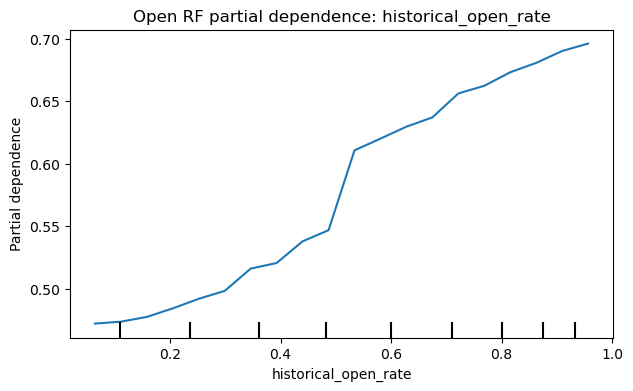

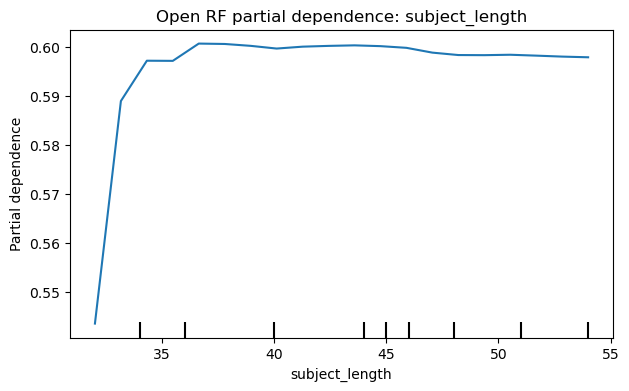

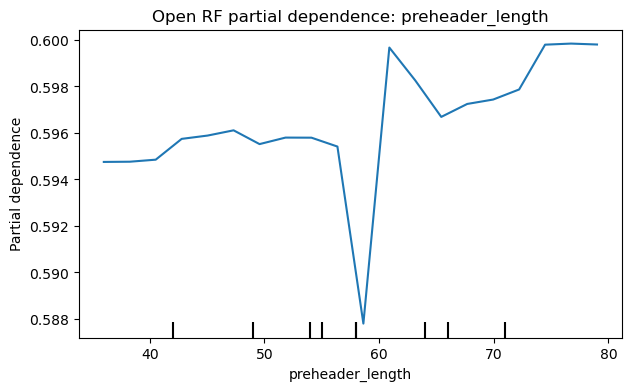

In [71]:
# open
open_effect_features = [
    "historical_open_rate",
    "subject_length",
    "preheader_length",
]

for feature in open_effect_features:
    fig, ax = plt.subplots(figsize=(7, 4))
    
    PartialDependenceDisplay.from_estimator(
        open_rf_model,
        X_open_test,
        features=[feature],
        kind="average",
        grid_resolution=20,
        ax=ax,
    )
    
    ax.set_title(f"Open RF partial dependence: {feature}")
    plt.show()

- Historical open rate: Users who historically open emails more frequently continue to have higher predicted probabilities of opening future emails. The relationship is approximately monotonic, indicating that prior engagement remains one of the strongest determinants of future opens.
- Subjectline length: Very short subject lines appear less effective. Beyond roughly 35–37 characters, additional subject length contributes little to predicted open probability.
- Preheader length exhibits only minor variation in predicted open probability, suggesting limited practical influence relative to historical engagement variables.

#### Click RF

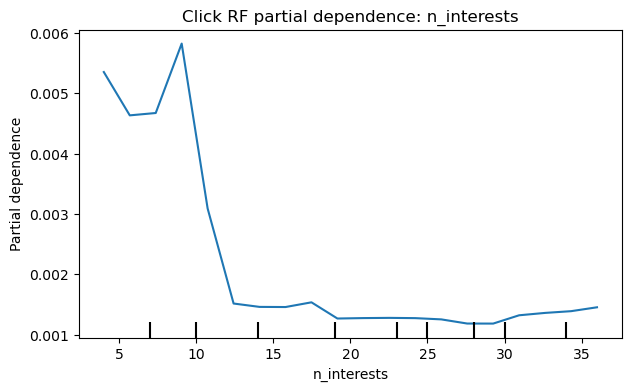

In [74]:
fig, ax = plt.subplots(figsize=(7, 4))

PartialDependenceDisplay.from_estimator(
    click_rf_model,
    X_click_test,
    features=["n_interests"],
    kind="average",
    grid_resolution=20,
    ax=ax,
)

ax.set_title("Click RF partial dependence: n_interests")
plt.show()

Users with fewer registered interests exhibit higher predicted click probabilities, while click propensity decreases substantially as the number of interests increases.

In [82]:
click_effect_features = ['historical_click_rate', 'prior_click_count']
for feature in click_effect_features:
    print("\n", feature)
    print(X_click_test[feature].describe())
    print("n unique:", X_click_test[feature].nunique(dropna=False))
    print("quantiles:")
    print(X_click_test[feature].quantile([0, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.995, 0.996, 0.997, 0.998, 0.999, 0.9999, 1]))


 historical_click_rate
count    288995.000000
mean          0.001625
std           0.023080
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           0.836735
Name: historical_click_rate, dtype: float64
n unique: 539
quantiles:
0.0000    0.000000
0.0500    0.000000
0.2500    0.000000
0.5000    0.000000
0.7500    0.000000
0.9500    0.000000
0.9900    0.035714
0.9950    0.076923
0.9960    0.111111
0.9970    0.163934
0.9980    0.264706
0.9990    0.416667
0.9999    0.722657
1.0000    0.836735
Name: historical_click_rate, dtype: float64

 prior_click_count
count    289973.000000
mean          0.062502
std           0.765100
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          45.000000
Name: prior_click_count, dtype: float64
n unique: 39
quantiles:
0.0000     0.0
0.0500     0.0
0.2500     0.0
0.5000     0.0
0.7500     0.0
0.9500     0.0
0.9900     2.0
0.9950     4.0
0.9960     5.0
0.9970    

In [84]:
hcr_q99 = click_profile_df["historical_click_rate"].quantile(0.99)
hcr_q999 = click_profile_df["historical_click_rate"].quantile(0.999)
hcr_max = click_profile_df["historical_click_rate"].max()

click_profile_df["historical_click_rate_profile_bin"] = pd.cut(
    click_profile_df["historical_click_rate"],
    bins=[-0.001, 0, hcr_q99, hcr_q999, hcr_max],
    labels=[
        "0",
        f"(0, q99={hcr_q99:.3f}]",
        f"(q99, q99.9={hcr_q999:.3f}]",
        f"(q99.9, max={hcr_max:.3f}]",
    ],
    include_lowest=True
)

click_profile_df["prior_click_count_profile_bin"] = pd.cut(
    click_profile_df["prior_click_count"],
    bins=[-0.001, 0, 1, 4, 9, np.inf],
    labels=["0", "1", "2-4", "5-9", "10+"],
    include_lowest=True
)

In [85]:
historical_click_rate_profile = create_prediction_profile(
    click_profile_df,
    feature="historical_click_rate_profile_bin",
    prediction_column="predicted_probability",
    target_column="actual_target",
)

prior_click_count_profile = create_prediction_profile(
    click_profile_df,
    feature="prior_click_count_profile_bin",
    prediction_column="predicted_probability",
    target_column="actual_target",
)

display(historical_click_rate_profile)
display(prior_click_count_profile)

/var/folders/kz/wylm8_ks1d7bmsgm23zfsgh80000gn/T/ipykernel_36626/1296367499.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(feature)
/var/folders/kz/wylm8_ks1d7bmsgm23zfsgh80000gn/T/ipykernel_36626/1296367499.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(feature)[target_column].mean()
/var/folders/kz/wylm8_ks1d7bmsgm23zfsgh80000gn/T/ipykernel_36626/1296367499.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and sil

,historical_click_rate_profile_bin,n_obs,mean_prediction,actual_rate
3,"(q99.9, max=0.837]",283,0.263292,0.095406
2,"(q99, q99.9=0.417]",2602,0.124733,0.032283
1,"(0, q99=0.036]",260,0.117191,0.207692
0,0,285850,0.000146,0.000105


,prior_click_count_profile_bin,n_obs,mean_prediction,actual_rate
4,10+,423,0.221482,0.078014
3,5-9,910,0.196322,0.014286
1,1,129,0.117274,0.271318
2,2-4,1683,0.084414,0.049911
0,0,286828,0.000159,0.000105


In [86]:
historical_click_rate_profile.to_csv(
    STAGE11_OUTPUT_DIR / "11_click_historical_click_rate_profile_v1.csv",
    index=False
)

prior_click_count_profile.to_csv(
    STAGE11_OUTPUT_DIR / "11_click_prior_click_count_profile_v1.csv",
    index=False
)

All groups with prior click activity exhibit substantially higher predicted click probabilities than users with no click history. Differences among the positive-click groups are less stable and should be interpreted cautiously due to small sample sizes.

Open

* Historical open rate shows a strong positive monotonic relationship with predicted opens.
* Subject length exhibits a threshold pattern, where very short subjects are associated with lower predicted opens, while longer subjects provide little additional benefit.
* Preheader length demonstrates only minor variation and appears less influential.

Click

* Historical click behaviour is the dominant predictor of future clicks.
* Users with any prior click activity receive substantially higher predicted click probabilities than users with no click history.
* The relationship between number of interests and predicted click probability is non-linear, with users having fewer interests displaying higher predicted click probabilities.

### 11.6.4 Effect-shape interpretation summary

The effect-shape checks support the earlier importance findings. For open prediction, historical_open_rate shows a clear positive relationship with predicted open probability, suggesting that prior open behaviour is strongly and monotonically related to future predicted opens. Subject length shows a threshold-like pattern: very short subject lines are associated with lower predicted open probability, while the curve largely plateaus beyond roughly the mid-30 character range. Preheader length varies only slightly, suggesting limited practical influence compared with historical engagement.

For click prediction, historical click behaviour remains the clearest signal. Because historical_click_rate and prior_click_count are highly zero-inflated, they were examined using binned observed profiles rather than smooth PDP curves. Users with no prior click history receive near-zero predicted click probabilities, while users with prior click activity receive substantially higher predicted probabilities. Differences among positive-click-history groups should be interpreted cautiously because those groups are much smaller.

The n_interests PDP suggests a nonlinear pattern, where users with fewer interests receive higher predicted click probabilities and predicted click probability decreases as the number of interests increases. This pattern should be treated as descriptive model behaviour rather than a causal effect.

Overall, the effect-shape checks suggest that Random Forest does capture some nonlinear or threshold-like patterns, especially for subject length and n_interests. However, the main substantive finding remains consistent with the earlier interpretation: historical engagement behaviour is the dominant driver of predicted engagement, while campaign/content and recipient features provide secondary information.

## 11.7 Optional subgroup/interaction checks

## 11.8 Click top-k segment profile

Stage 10 showed that Logistic Regression and Random Forest had similar aggregate click performance, but Random Forest captured more true clickers in the narrowest top-k targeting segments.

This section profiles the highest-ranked click recipients to understand what characterises the users selected by each model. The goal is not to select a new model, but to interpret the practical targeting differences between Logistic Regression and Random Forest.

In [87]:
# top-k flags
click_topk_profile_df = X_click_test.copy()
click_topk_profile_df["y_true"] = click_predictions["y_true"].values
click_topk_profile_df["proba_logistic_C"] = click_predictions["proba_logistic_C"].values
click_topk_profile_df["proba_random_forest_C"] = click_predictions["proba_random_forest_C"].values

TOPK_RATES = [0.001, 0.005, 0.01]  # 0.1%, 0.5%, 1%

for rate in TOPK_RATES:
    k = int(np.ceil(len(click_topk_profile_df) * rate))
    
    lr_col = f"top_{rate:.3%}_logistic"
    rf_col = f"top_{rate:.3%}_rf"
    
    click_topk_profile_df[lr_col] = False
    click_topk_profile_df[rf_col] = False
    
    lr_top_idx = click_topk_profile_df["proba_logistic_C"].nlargest(k).index
    rf_top_idx = click_topk_profile_df["proba_random_forest_C"].nlargest(k).index
    
    click_topk_profile_df.loc[lr_top_idx, lr_col] = True
    click_topk_profile_df.loc[rf_top_idx, rf_col] = True

click_topk_profile_df.head()

,age_clean,n_interests,subject_length,preheader_length,prior_email_count,prior_open_count,prior_click_count,historical_open_rate,historical_click_rate,gender,...,is_first_email,y_true,proba_logistic_C,proba_random_forest_C,top_0.100%_logistic,top_0.100%_rf,top_0.500%_logistic,top_0.500%_rf,top_1.000%_logistic,top_1.000%_rf
50,NaN,17,59,93,50,22.0,0.0,0.440000,0.0,male,...,False,0.0,0.000347,0.001734,False,False,False,False,False,False
51,NaN,17,51,55,51,22.0,0.0,0.431373,0.0,male,...,False,0.0,0.000264,0.000029,False,False,False,False,False,False
52,NaN,17,44,42,52,22.0,0.0,0.423077,0.0,male,...,False,0.0,0.000921,0.000023,False,False,False,False,False,False
53,NaN,17,54,71,53,22.0,0.0,0.415094,0.0,male,...,False,0.0,0.000226,0.001295,False,False,False,False,False,False
54,NaN,17,44,42,54,22.0,0.0,0.407407,0.0,male,...,False,0.0,0.000883,0.000048,False,False,False,False,False,False


In [88]:
def summarise_topk_segment(df, flag_col, model_name, topk_label):
    segment = df[df[flag_col]].copy()
    
    summary = {
        "model_name": model_name,
        "topk_label": topk_label,
        "selected_count": len(segment),
        "actual_clicks": segment["y_true"].sum(),
        "actual_click_rate": segment["y_true"].mean(),
        "mean_historical_open_rate": segment["historical_open_rate"].mean(),
        "mean_historical_click_rate": segment["historical_click_rate"].mean(),
        "mean_prior_email_count": segment["prior_email_count"].mean(),
        "mean_prior_open_count": segment["prior_open_count"].mean(),
        "mean_prior_click_count": segment["prior_click_count"].mean(),
        "share_had_prior_click": segment["had_prior_click"].mean(),
        "mean_n_interests": segment["n_interests"].mean(),
        "share_interest_topic_match": segment["interest_topic_match"].mean(),
    }
    
    return summary

In [89]:
topk_profile_rows = []

for rate in TOPK_RATES:
    topk_label = f"top_{rate:.1%}"
    
    lr_flag = f"top_{rate:.3%}_logistic"
    rf_flag = f"top_{rate:.3%}_rf"
    
    topk_profile_rows.append(
        summarise_topk_segment(
            click_topk_profile_df,
            flag_col=lr_flag,
            model_name="logistic_regression__C_expanded",
            topk_label=topk_label,
        )
    )
    
    topk_profile_rows.append(
        summarise_topk_segment(
            click_topk_profile_df,
            flag_col=rf_flag,
            model_name="random_forest__C_expanded",
            topk_label=topk_label,
        )
    )

click_topk_segment_profile = pd.DataFrame(topk_profile_rows)

display(click_topk_segment_profile)

,model_name,topk_label,selected_count,actual_clicks,actual_click_rate,mean_historical_open_rate,mean_historical_click_rate,mean_prior_email_count,mean_prior_open_count,mean_prior_click_count,share_had_prior_click,mean_n_interests,share_interest_topic_match
0,logistic_regression__C_expanded,top_0.1%,290,32.0,0.110345,0.500556,0.515193,28.893103,12.508065,13.331034,1.000000,11.444828,0.834483
1,random_forest__C_expanded,top_0.1%,290,40.0,0.137931,0.197684,0.277354,41.362069,9.195122,10.558621,1.000000,9.986207,0.706897
2,logistic_regression__C_expanded,top_0.5%,1450,103.0,0.071034,0.334864,0.254279,43.426897,13.616288,8.355172,1.000000,12.804138,0.865517
3,random_forest__C_expanded,top_0.5%,1450,117.0,0.080690,0.333019,0.235990,43.236552,14.437179,7.535172,0.997931,12.419310,0.819310
4,logistic_regression__C_expanded,top_1.0%,2900,153.0,0.052759,0.379778,0.158388,53.016897,20.132992,5.981379,1.000000,18.617931,0.892414
5,random_forest__C_expanded,top_1.0%,2900,161.0,0.055517,0.379778,0.157921,50.575517,19.926063,5.752414,0.931724,17.664138,0.849310


In the highest-ranked click segment (top 0.1%), Random Forest achieved a higher observed click rate (13.8%) than Logistic Regression (11.0%). Interestingly, the users selected by Random Forest did not necessarily have higher average historical click rates or prior click counts. This suggests that Random Forest may identify click-prone recipients through combinations of multiple characteristics rather than relying solely on the strongest individual behavioural variables. However, the advantage diminished as larger top-k segments were considered, indicating that the practical differences between the models were concentrated among the highest-ranked recipients.

Random Forest appears to rank the very highest-probability clickers slightly more effectively, potentially through nonlinear combinations of features, but the overall profile of selected recipients remains broadly similar across models. 

RF has a small advantage only in the narrowest top-k segments, especially top 0.1%–1%. At broader targeting levels such as 5% and 10%, Logistic Regression performs as well as or better than RF.

### Overlap between LR and RF top-k selections

In [90]:
topk_overlap_rows = []

for rate in TOPK_RATES:
    lr_flag = f"top_{rate:.3%}_logistic"
    rf_flag = f"top_{rate:.3%}_rf"
    
    lr_selected = click_topk_profile_df[lr_flag]
    rf_selected = click_topk_profile_df[rf_flag]
    
    overlap = (lr_selected & rf_selected).sum()
    lr_count = lr_selected.sum()
    rf_count = rf_selected.sum()
    
    topk_overlap_rows.append({
        "topk_label": f"top_{rate:.1%}",
        "lr_selected": lr_count,
        "rf_selected": rf_count,
        "overlap_count": overlap,
        "overlap_share_of_lr": overlap / lr_count,
        "overlap_share_of_rf": overlap / rf_count,
    })

topk_overlap_summary = pd.DataFrame(topk_overlap_rows)
display(topk_overlap_summary)

,topk_label,lr_selected,rf_selected,overlap_count,overlap_share_of_lr,overlap_share_of_rf
0,top_0.1%,290,290,79,0.272414,0.272414
1,top_0.5%,1450,1450,1057,0.728966,0.728966
2,top_1.0%,2900,2900,2530,0.872414,0.872414


### Interpretation of top-k overlap

The top-k overlap shows that Logistic Regression and Random Forest select very different recipients only at the narrowest targeting level. In the top 0.1% segment, only 27.2% of selected recipients overlap between the two models, while Random Forest captures more actual clicks. This suggests that Random Forest adds most targeting value when the business objective is to identify a very small group of highest-propensity clickers.

At broader targeting levels, the overlap increases substantially: 72.9% at top 0.5% and 87.2% at top 1.0%. This indicates that the two models largely agree on high-propensity recipients once the selected segment becomes larger. Therefore, Random Forest does not identify a completely different audience overall; its added value is concentrated in the ordering of the most extreme top-ranked recipients.

In [91]:
# inspect top 0.1%
TOPK_SPLIT_RATE = 0.001

lr_flag = f"top_{TOPK_SPLIT_RATE:.3%}_logistic"
rf_flag = f"top_{TOPK_SPLIT_RATE:.3%}_rf"

top01_split_df = click_topk_profile_df.copy()

top01_split_df["top01_segment"] = np.select(
    [
        top01_split_df[lr_flag] & top01_split_df[rf_flag],
        top01_split_df[lr_flag] & ~top01_split_df[rf_flag],
        ~top01_split_df[lr_flag] & top01_split_df[rf_flag],
    ],
    [
        "selected_by_both",
        "logistic_only",
        "rf_only",
    ],
    default="not_selected"
)

top01_selected_profile = (
    top01_split_df[top01_split_df["top01_segment"] != "not_selected"]
    .groupby("top01_segment")
    .agg(
        n_obs=("top01_segment", "size"),
        actual_clicks=("y_true", "sum"),
        actual_click_rate=("y_true", "mean"),
        mean_logistic_probability=("proba_logistic_C", "mean"),
        mean_rf_probability=("proba_random_forest_C", "mean"),
        mean_historical_click_rate=("historical_click_rate", "mean"),
        mean_prior_click_count=("prior_click_count", "mean"),
        share_had_prior_click=("had_prior_click", "mean"),
        mean_n_interests=("n_interests", "mean"),
        share_interest_topic_match=("interest_topic_match", "mean"),
    )
    .reset_index()
    .sort_values("actual_click_rate", ascending=False)
)

display(top01_selected_profile)

,top01_segment,n_obs,actual_clicks,actual_click_rate,mean_logistic_probability,mean_rf_probability,mean_historical_click_rate,mean_prior_click_count,share_had_prior_click,mean_n_interests,share_interest_topic_match
2,selected_by_both,79,27.0,0.341772,0.535124,0.533235,0.528171,22.012658,1.0,19.873418,0.974684
1,rf_only,211,13.0,0.061611,0.130886,0.454138,0.183446,6.270142,1.0,6.284360,0.606635
0,logistic_only,211,5.0,0.023697,0.395747,0.195765,0.510334,10.080569,1.0,8.289100,0.781991


In [92]:
top01_selected_profile.to_csv(
    STAGE11_OUTPUT_DIR / "11_click_top01_lr_rf_overlap_segment_profile_v1.csv",
    index=False
)

Comparison of recipients uniquely selected by each model

To better understand the differences between the ranking behaviour of Logistic Regression and Random Forest, the top 0.1% highest-ranked recipients from each model were compared. The overlap analysis showed that only 79 of the 290 recipients selected by each model were shared, indicating substantial disagreement in the extreme upper tail of the ranking.

Recipients selected by both models achieved the highest click rate (34.2%), suggesting that both models consistently identified a core group of highly engaged recipients. However, among recipients selected by only one model, those selected exclusively by Random Forest achieved a click rate of 6.2%, compared with only 2.4% for recipients selected exclusively by Logistic Regression.

Interestingly, the recipients selected only by Logistic Regression exhibited higher historical click rates and higher prior click counts than those selected only by Random Forest. This suggests that Logistic Regression tended to rank recipients highly based on strong historical engagement signals alone. In contrast, Random Forest appeared to discount some of these recipients while prioritising others with weaker historical engagement but a higher realised click rate in the test set.

These findings suggest that the advantage of Random Forest does not arise from identifying completely different important variables. Instead, both models rely on largely similar engagement-related predictors. The difference appears to lie in how these predictors are combined when ranking the highest-propensity recipients. Random Forest was able to produce a more effective ordering of the most extreme click candidates, which resulted in higher click capture within the smallest targeting segment.

Aggregate metrics show limited additional predictive value from Random Forest.
Interpretation shows similar broad feature drivers across models.
However, top-k analysis shows Random Forest can add practical value in very narrow click-targeting scenarios.

Flexible tree-based models did not consistently outperform Logistic Regression across all evaluation perspectives. Their added value was limited and context-specific: Random Forest provided little additional explanatory value at the broad feature-driver level, but it improved ranking among the smallest high-propensity click segments. This suggests that flexible models may be most useful when the business objective is narrow top-k targeting rather than general probability estimation or broad engagement prediction.

Model complexity only pays off in specific targeting contexts.

## 11.9 H-statistic interaction analysis

This section formally checks whether the Random Forest models rely on non-additive relationships between selected predictors. The H-statistic is used as an exploratory diagnostic of interaction strength. It measures whether the joint effect of two features differs from the sum of their individual effects.

The analysis is limited to pre-specified, theoretically meaningful feature pairs and model-informed pairs identified in earlier interpretation sections. The goal is not to exhaustively search all possible interactions, but to assess whether interaction-like model behaviour is present for substantively relevant feature combinations.

The selected pairs are:

- Open prediction:
  - historical_open_bucket × prior_email_frequency_bucket       # original theory-driven pair
  - campaign_topic × age_group                                  # original theory-driven pair
  - historical_open_bucket × interest_topic_match
  - historical_open_bucket × subject_length_group

- Click prediction:
  - had_prior_click × interest_topic_match
  - had_prior_click × n_interests_group
  - historical_click_rate_bin × n_interests_group

These pairs were selected because they combine historical engagement signals with campaign-content or recipient-level characteristics, which directly reflects the research question. Pairs involving near-duplicate or mechanically related features were avoided to reduce redundant interpretation.

The H-statistic is interpreted cautiously. It describes interaction behaviour in the fitted model and does not imply causal interaction effects.

In [93]:
OPEN_INTERACTION_PAIRS = [
    ("historical_open_bucket", "prior_email_frequency_bucket"),  # original theory-driven pair
    ("campaign_topic", "age_group"),                            # original theory-driven pair
    ("historical_open_bucket", "interest_topic_match"),          # model-informed pair
    ("historical_open_bucket", "subject_length_group"),          # model-informed pair
]

CLICK_INTERACTION_PAIRS = [
    ("had_prior_click", "interest_topic_match"),
    ("had_prior_click", "n_interests"),
    ("historical_click_rate", "n_interests"),
]

In [94]:
for pair in OPEN_INTERACTION_PAIRS:
    print(pair, all(feature in X_open_test.columns for feature in pair))

for pair in CLICK_INTERACTION_PAIRS:
    print(pair, all(feature in X_click_test.columns for feature in pair))

('historical_open_bucket', 'prior_email_frequency_bucket') True
('campaign_topic', 'age_group') True
('historical_open_bucket', 'interest_topic_match') True
('historical_open_bucket', 'subject_length_group') True
('had_prior_click', 'interest_topic_match') True
('had_prior_click', 'n_interests') True
('historical_click_rate', 'n_interests') True


### 11.9.1 Candidate pool

In [96]:
OPEN_INTERACTION_FEATURES = [
    "historical_open_bucket",
    "prior_email_frequency_bucket",
    "interest_topic_match",
    "subject_length_group",
    "campaign_topic",
    "age_group",
]

In [97]:
CLICK_INTERACTION_FEATURES = [
    "historical_click_rate",
    "prior_click_count",
    "had_prior_click",
    "n_interests",
    "interest_topic_match",
    "campaign_topic",
]

In [98]:
from itertools import combinations

open_pairs = list(combinations(OPEN_INTERACTION_FEATURES, 2))
click_pairs = list(combinations(CLICK_INTERACTION_FEATURES, 2))

print(f"Open pairs: {len(open_pairs)}")
print(f"Click pairs: {len(click_pairs)}")

Open pairs: 15
Click pairs: 15


### 11.9.2 Check

In [105]:
print(X_open_test.shape)
print(X_click_test.shape)

(275718, 28)
(289973, 28)


In [106]:
INTERACTION_SAMPLE_SIZE = 20000

X_open_interaction = X_open_test.sample(
    n=min(INTERACTION_SAMPLE_SIZE, len(X_open_test)),
    random_state=RANDOM_STATE
)

X_click_interaction = X_click_test.sample(
    n=min(INTERACTION_SAMPLE_SIZE, len(X_click_test)),
    random_state=RANDOM_STATE
)

print(X_open_interaction.shape)
print(X_click_interaction.shape)

(20000, 28)
(20000, 28)


In [107]:
from itertools import combinations

OPEN_INTERACTION_FEATURES = [
    "historical_open_bucket",
    "prior_email_frequency_bucket",
    "interest_topic_match",
    "subject_length_group",
    "campaign_topic",
    "age_group",
]

CLICK_INTERACTION_FEATURES = [
    "historical_click_rate",
    "prior_click_count",
    "had_prior_click",
    "n_interests",
    "interest_topic_match",
    "campaign_topic",
]

open_interaction_pairs = list(combinations(OPEN_INTERACTION_FEATURES, 2))
click_interaction_pairs = list(combinations(CLICK_INTERACTION_FEATURES, 2))

print("Open interaction pairs:", len(open_interaction_pairs))
print("Click interaction pairs:", len(click_interaction_pairs))

Open interaction pairs: 15
Click interaction pairs: 15


Because the final test sets contain more than 275,000 observations, interaction screening is performed on a fixed random sample of 20,000 observations for computational feasibility. The sample is used only for post-hoc interpretation and does not affect model training, model selection, or final performance evaluation.

### 11.9.2 PDP-based interaction screening

A PDP-based interaction score is used as an exploratory measure of non-additive model behaviour. For each feature pair, the two-way partial dependence surface is compared with the corresponding one-way partial dependence functions. Larger scores indicate that the joint effect cannot be well explained by the sum of the individual feature effects.

The score is intended for interaction screening rather than formal statistical testing.

In [108]:
import numpy as np
import pandas as pd

from sklearn.inspection import partial_dependence

In [109]:
def interaction_score_pdp(
    model,
    X,
    feature_a,
    feature_b,
    grid_resolution=10
):
    """
    PDP-based interaction score.

    Higher values indicate stronger non-additive behaviour.
    """

    # 1D PDPs
    pd_a = partial_dependence(
        model,
        X,
        [feature_a],
        grid_resolution=grid_resolution,
        kind="average"
    )

    pd_b = partial_dependence(
        model,
        X,
        [feature_b],
        grid_resolution=grid_resolution,
        kind="average"
    )

    # 2D PDP
    pd_ab = partial_dependence(
        model,
        X,
        [(feature_a, feature_b)],
        grid_resolution=grid_resolution,
        kind="average"
    )

    f_a = pd_a["average"][0]
    f_b = pd_b["average"][0]

    f_ab = pd_ab["average"][0]

    # broadcast
    additive_surface = (
        f_a.reshape(-1, 1)
        + f_b.reshape(1, -1)
    )

    residual_surface = f_ab - additive_surface

    numerator = np.var(residual_surface)
    denominator = np.var(f_ab)

    score = (
        numerator / denominator
        if denominator > 0
        else 0.0
    )

    return score

In [111]:
CATEGORICAL_INTERACTION_FEATURES = [
    "historical_open_bucket",
    "prior_email_frequency_bucket",
    "campaign_topic",
    "age_group",
    "subject_length_group",
]

for col in CATEGORICAL_INTERACTION_FEATURES:
    if col in X_open_interaction.columns:
        X_open_interaction[col] = (
            X_open_interaction[col]
            .astype("object")
            .where(X_open_interaction[col].notna(), "Missing")
            .astype(str)
        )

for col in CATEGORICAL_INTERACTION_FEATURES:
    if col in X_click_interaction.columns:
        X_click_interaction[col] = (
            X_click_interaction[col]
            .astype("object")
            .where(X_click_interaction[col].notna(), "Missing")
            .astype(str)
        )

In [114]:
def get_feature_index(X, feature):
    return list(X.columns).index(feature)

interaction_score_pdp(
    open_rf_model,
    X_open_interaction,
    get_feature_index(X_open_interaction, "historical_open_bucket"),
    get_feature_index(X_open_interaction, "prior_email_frequency_bucket")
)

0.0004893092181339474

In [115]:
def interaction_score_pdp(
    model,
    X,
    feature_a,
    feature_b,
    grid_resolution=10
):
    """
    PDP-based interaction score using column indices internally.
    """

    feature_a_idx = list(X.columns).index(feature_a) if isinstance(feature_a, str) else feature_a
    feature_b_idx = list(X.columns).index(feature_b) if isinstance(feature_b, str) else feature_b

    pd_a = partial_dependence(
        model,
        X,
        [feature_a_idx],
        grid_resolution=grid_resolution,
        kind="average"
    )

    pd_b = partial_dependence(
        model,
        X,
        [feature_b_idx],
        grid_resolution=grid_resolution,
        kind="average"
    )

    pd_ab = partial_dependence(
        model,
        X,
        [(feature_a_idx, feature_b_idx)],
        grid_resolution=grid_resolution,
        kind="average"
    )

    f_a = pd_a["average"][0]
    f_b = pd_b["average"][0]
    f_ab = pd_ab["average"][0]

    additive_surface = (
        f_a.reshape(-1, 1)
        + f_b.reshape(1, -1)
    )

    residual_surface = f_ab - additive_surface

    numerator = np.var(residual_surface)
    denominator = np.var(f_ab)

    score = numerator / denominator if denominator > 0 else 0.0

    return score

In [116]:
interaction_score_pdp(
    open_rf_model,
    X_open_interaction,
    "historical_open_bucket",
    "prior_email_frequency_bucket"
)

0.0004893092181339481

In [117]:
def screen_interactions(model, X, pairs, target_name, grid_resolution=10):
    rows = []
    
    for feature_a, feature_b in pairs:
        try:
            score = interaction_score_pdp(
                model=model,
                X=X,
                feature_a=feature_a,
                feature_b=feature_b,
                grid_resolution=grid_resolution,
            )
            
            rows.append({
                "target": target_name,
                "feature_a": feature_a,
                "feature_b": feature_b,
                "interaction_score": score,
                "status": "ok",
            })
        
        except Exception as e:
            rows.append({
                "target": target_name,
                "feature_a": feature_a,
                "feature_b": feature_b,
                "interaction_score": np.nan,
                "status": f"error: {type(e).__name__}: {str(e)[:120]}",
            })
    
    return (
        pd.DataFrame(rows)
        .sort_values("interaction_score", ascending=False)
        .reset_index(drop=True)
    )

In [118]:
open_interaction_scores = screen_interactions(
    model=open_rf_model,
    X=X_open_interaction,
    pairs=open_interaction_pairs,
    target_name="open",
    grid_resolution=10,
)

click_interaction_scores = screen_interactions(
    model=click_rf_model,
    X=X_click_interaction,
    pairs=click_interaction_pairs,
    target_name="click",
    grid_resolution=10,
)

display(open_interaction_scores)
display(click_interaction_scores)

,target,feature_a,feature_b,interaction_score,status
0,open,subject_length_group,campaign_topic,0.068179,ok
1,open,prior_email_frequency_bucket,campaign_topic,0.025939,ok
2,open,prior_email_frequency_bucket,subject_length_group,0.010234,ok
3,open,historical_open_bucket,interest_topic_match,0.006698,ok
4,open,prior_email_frequency_bucket,age_group,0.005450,ok
5,open,interest_topic_match,campaign_topic,0.005225,ok
6,open,campaign_topic,age_group,0.004646,ok
7,open,interest_topic_match,subject_length_group,0.003322,ok
8,open,prior_email_frequency_bucket,interest_topic_match,0.003272,ok
9,open,subject_length_group,age_group,0.001947,ok


,target,feature_a,feature_b,interaction_score,status
0,click,had_prior_click,n_interests,0.225146,ok
1,click,n_interests,campaign_topic,0.012636,ok
2,click,had_prior_click,campaign_topic,0.012390,ok
3,click,interest_topic_match,campaign_topic,0.006326,ok
4,click,had_prior_click,interest_topic_match,0.002730,ok
5,click,n_interests,interest_topic_match,0.000851,ok
6,click,historical_click_rate,prior_click_count,NaN,error: ValueError: percentiles are too close t...
7,click,historical_click_rate,had_prior_click,NaN,error: ValueError: percentiles are too close t...
8,click,historical_click_rate,n_interests,NaN,error: ValueError: percentiles are too close t...
9,click,historical_click_rate,interest_topic_match,NaN,error: ValueError: percentiles are too close t...


In [119]:
# Full-test interaction screening
# Warning: this may take several minutes.

open_interaction_scores_full = screen_interactions(
    model=open_rf_model,
    X=X_open_test,
    pairs=open_interaction_pairs,
    target_name="open",
    grid_resolution=10,
)

click_interaction_scores_full = screen_interactions(
    model=click_rf_model,
    X=X_click_test,
    pairs=click_interaction_pairs,
    target_name="click",
    grid_resolution=10,
)

display(open_interaction_scores_full)
display(click_interaction_scores_full)

,target,feature_a,feature_b,interaction_score,status
0,open,subject_length_group,campaign_topic,0.068632,ok
1,open,prior_email_frequency_bucket,campaign_topic,0.026160,ok
2,open,prior_email_frequency_bucket,subject_length_group,0.010103,ok
3,open,interest_topic_match,campaign_topic,0.005192,ok
4,open,interest_topic_match,subject_length_group,0.003342,ok
5,open,prior_email_frequency_bucket,interest_topic_match,0.003313,ok
6,open,historical_open_bucket,prior_email_frequency_bucket,NaN,error: ValueError: The column #0 contains mixe...
7,open,historical_open_bucket,interest_topic_match,NaN,error: ValueError: The column #0 contains mixe...
8,open,historical_open_bucket,subject_length_group,NaN,error: ValueError: The column #0 contains mixe...
9,open,historical_open_bucket,campaign_topic,NaN,error: ValueError: The column #0 contains mixe...


,target,feature_a,feature_b,interaction_score,status
0,click,had_prior_click,n_interests,0.225505,ok
1,click,n_interests,campaign_topic,0.012468,ok
2,click,had_prior_click,campaign_topic,0.012351,ok
3,click,interest_topic_match,campaign_topic,0.005961,ok
4,click,had_prior_click,interest_topic_match,0.002771,ok
5,click,n_interests,interest_topic_match,0.000924,ok
6,click,historical_click_rate,prior_click_count,NaN,error: ValueError: percentiles are too close t...
7,click,historical_click_rate,had_prior_click,NaN,error: ValueError: percentiles are too close t...
8,click,historical_click_rate,n_interests,NaN,error: ValueError: percentiles are too close t...
9,click,historical_click_rate,interest_topic_match,NaN,error: ValueError: percentiles are too close t...


In [120]:
X_open_interaction_full = X_open_test.copy()
X_click_interaction_full = X_click_test.copy()

CATEGORICAL_INTERACTION_FEATURES = [
    "historical_open_bucket",
    "prior_email_frequency_bucket",
    "campaign_topic",
    "age_group",
    "subject_length_group",
]

for col in CATEGORICAL_INTERACTION_FEATURES:
    if col in X_open_interaction_full.columns:
        X_open_interaction_full[col] = (
            X_open_interaction_full[col]
            .astype("object")
            .where(X_open_interaction_full[col].notna(), "Missing")
            .astype(str)
        )

    if col in X_click_interaction_full.columns:
        X_click_interaction_full[col] = (
            X_click_interaction_full[col]
            .astype("object")
            .where(X_click_interaction_full[col].notna(), "Missing")
            .astype(str)
        )

In [121]:
open_interaction_scores_full = screen_interactions(
    model=open_rf_model,
    X=X_open_interaction_full,
    pairs=open_interaction_pairs,
    target_name="open",
    grid_resolution=10,
)

display(open_interaction_scores_full)

,target,feature_a,feature_b,interaction_score,status
0,open,subject_length_group,campaign_topic,0.068632,ok
1,open,prior_email_frequency_bucket,campaign_topic,0.026160,ok
2,open,prior_email_frequency_bucket,subject_length_group,0.010103,ok
3,open,historical_open_bucket,interest_topic_match,0.006666,ok
4,open,prior_email_frequency_bucket,age_group,0.005506,ok
5,open,interest_topic_match,campaign_topic,0.005192,ok
6,open,campaign_topic,age_group,0.004676,ok
7,open,interest_topic_match,subject_length_group,0.003342,ok
8,open,prior_email_frequency_bucket,interest_topic_match,0.003313,ok
9,open,subject_length_group,age_group,0.001913,ok


Theory-driven interaction engineering does not necessarily identify the most important interaction effects. The interaction screening suggests that the strongest interaction discovered by the Random Forest involved subject length group and campaign topic, whereas the manually specified interaction between historical open bucket and prior email frequency bucket exhibited almost no interaction signal.

The strongest interaction discovered by the Random Forest was subject_length_group × campaign_topic, whereas the manually specified interaction historical_open_bucket × prior_email_frequency_bucket exhibited almost no interaction signal (0.00049). This suggests that interaction effects identified through model-based screening may differ substantially from those specified a priori during feature engineering.

In [122]:
for col in ["historical_click_rate", "prior_click_count"]:
    print("\n", col)
    print(X_click_test[col].describe())
    print("n_unique =", X_click_test[col].nunique())
    print("top values:")
    print(X_click_test[col].value_counts().head(10))


 historical_click_rate
count    288995.000000
mean          0.001625
std           0.023080
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           0.836735
Name: historical_click_rate, dtype: float64
n_unique = 538
top values:
historical_click_rate
0.000000    285850
0.047619        50
0.045455        44
0.050000        42
0.052632        42
0.055556        40
0.051724        38
0.046154        37
0.050847        37
0.043478        35
Name: count, dtype: int64

 prior_click_count
count    289973.000000
mean          0.062502
std           0.765100
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          45.000000
Name: prior_click_count, dtype: float64
n_unique = 39
top values:
prior_click_count
0.0     286828
3.0       1083
9.0        535
4.0        408
5.0        226
10.0       202
2.0        192
1.0        129
6.0         79
7.0         70
Name: count, dtype: int64


### Interpretation of the PDP-based interaction score

The interaction score used here is an exploratory approximation inspired by Friedman’s H-statistic. For each feature pair, the Random Forest’s two-dimensional partial dependence surface is compared with an additive approximation based on the two corresponding one-dimensional partial dependence functions.

Conceptually, the score measures how much of the variation in the joint prediction surface cannot be explained by adding the two separate main effects. A score close to zero suggests that the model behaves approximately additively for that pair, while a larger score suggests stronger non-additive model behaviour.

The score should not be interpreted as feature importance, performance gain, or causal interaction strength. It is used only as a screening tool to identify candidate interactions for visual inspection. Therefore, pairs with higher scores are followed by interaction plots to assess whether the detected non-additive behaviour is interpretable and practically meaningful.

For click prediction, several pairs involving historical_click_rate and prior_click_count could not be evaluated with the PDP-based score because these variables were extremely zero-inflated: approximately 99% of final-test observations had zero values. As a result, the PDP grid could not be constructed reliably. These variables were therefore interpreted through observed profiles in Section 11.6 rather than through PDP-based interaction scores.

### 11.9.3 Interaction plots for selected pairs

The highest-ranked interaction candidates are visualised to inspect the shape of the non-additive model behaviour. Only selected pairs are plotted because the interaction score is used for screening rather than exhaustive interpretation.

In [123]:
OPEN_INTERACTION_PLOTS = [
    ("subject_length_group", "campaign_topic"),
    ("prior_email_frequency_bucket", "campaign_topic"),
]

CLICK_INTERACTION_PLOTS = [
    ("had_prior_click", "n_interests"),
    ("had_prior_click", "campaign_topic"),
]

In [124]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

def plot_2d_pdp(model, X, feature_pair, title):
    fig, ax = plt.subplots(figsize=(8, 5))
    
    PartialDependenceDisplay.from_estimator(
        model,
        X,
        features=[feature_pair],
        kind="average",
        grid_resolution=10,
        ax=ax,
    )
    
    ax.set_title(title)
    plt.show()

TypeError: can't multiply sequence by non-int of type 'float'

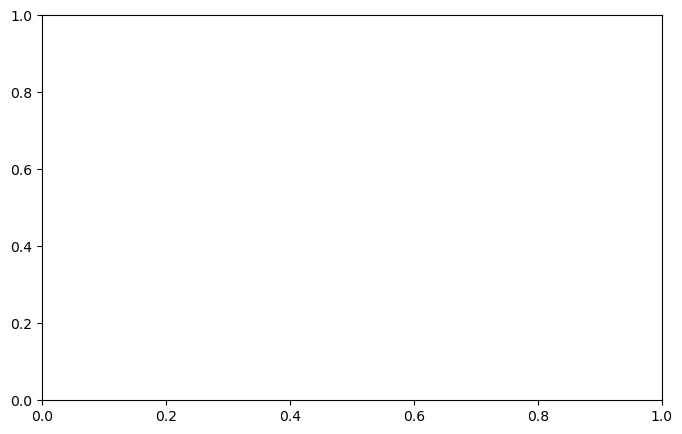

In [125]:
for pair in OPEN_INTERACTION_PLOTS:
    plot_2d_pdp(
        model=open_rf_model,
        X=X_open_interaction_full,
        feature_pair=pair,
        title=f"Open RF 2D PDP: {pair[0]} × {pair[1]}",
    )

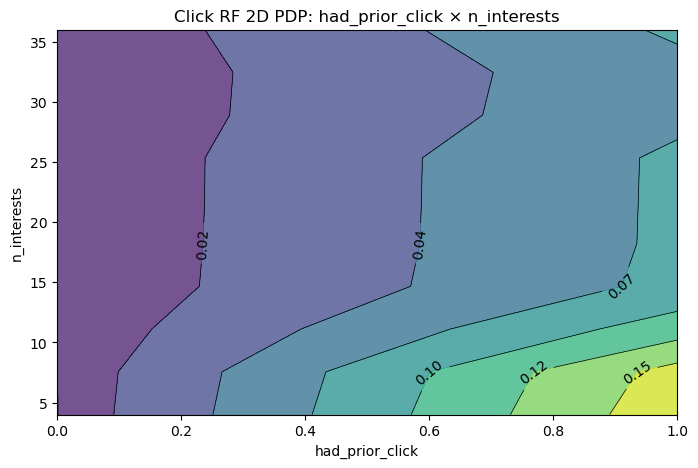

TypeError: can't multiply sequence by non-int of type 'float'

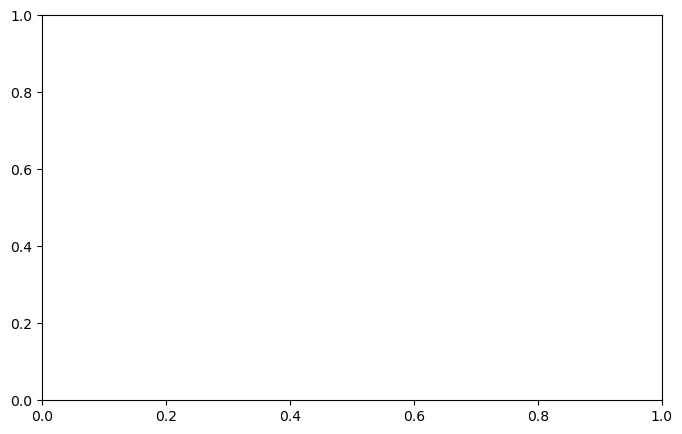

In [126]:
for pair in CLICK_INTERACTION_PLOTS:
    plot_2d_pdp(
        model=click_rf_model,
        X=X_click_interaction_full,
        feature_pair=pair,
        title=f"Click RF 2D PDP: {pair[0]} × {pair[1]}",
    )

In [127]:
def create_interaction_profile(
    df,
    feature_a,
    feature_b,
    prediction_column,
    target_column=None
):
    grouped = (
        df
        .groupby([feature_a, feature_b], dropna=False)
        .agg(
            n_obs=(prediction_column, "size"),
            mean_prediction=(prediction_column, "mean"),
        )
        .reset_index()
    )
    
    if target_column is not None:
        actual = (
            df
            .groupby([feature_a, feature_b], dropna=False)[target_column]
            .mean()
            .reset_index(name="actual_rate")
        )
        grouped = grouped.merge(actual, on=[feature_a, feature_b], how="left")
    
    return grouped

In [128]:
open_interaction_profile_df = X_open_test.copy()
open_interaction_profile_df["predicted_probability"] = open_predictions["proba_random_forest_C"].values
open_interaction_profile_df["actual_target"] = open_predictions["y_true"].values

click_interaction_profile_df = X_click_test.copy()
click_interaction_profile_df["predicted_probability"] = click_predictions["proba_random_forest_C"].values
click_interaction_profile_df["actual_target"] = click_predictions["y_true"].values

In [129]:
open_subject_topic_profile = create_interaction_profile(
    open_interaction_profile_df,
    "subject_length_group",
    "campaign_topic",
    "predicted_probability",
    "actual_target",
)

open_frequency_topic_profile = create_interaction_profile(
    open_interaction_profile_df,
    "prior_email_frequency_bucket",
    "campaign_topic",
    "predicted_probability",
    "actual_target",
)

click_prior_interest_profile = create_interaction_profile(
    click_interaction_profile_df,
    "had_prior_click",
    "n_interests",
    "predicted_probability",
    "actual_target",
)

click_prior_topic_profile = create_interaction_profile(
    click_interaction_profile_df,
    "had_prior_click",
    "campaign_topic",
    "predicted_probability",
    "actual_target",
)

display(open_subject_topic_profile)
display(open_frequency_topic_profile)
display(click_prior_interest_profile)
display(click_prior_topic_profile)

/var/folders/kz/wylm8_ks1d7bmsgm23zfsgh80000gn/T/ipykernel_36626/50307344.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([feature_a, feature_b], dropna=False)
/var/folders/kz/wylm8_ks1d7bmsgm23zfsgh80000gn/T/ipykernel_36626/50307344.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([feature_a, feature_b], dropna=False)[target_column]
/var/folders/kz/wylm8_ks1d7bmsgm23zfsgh80000gn/T/ipykernel_36626/50307344.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or obse

,subject_length_group,campaign_topic,n_obs,mean_prediction,actual_rate
0,short,Automotive & Mobility,0,NaN,NaN
1,short,Business,0,NaN,NaN
2,short,Finance & Investment,0,NaN,NaN
3,short,Food & Beverages,0,NaN,NaN
4,short,Lottery & Games,0,NaN,NaN
5,short,Media & Publishing,20143,0.496429,0.064638
6,short,Retail & Promotion,21684,0.574338,0.447749
7,medium,Automotive & Mobility,36558,0.641232,0.529569
8,medium,Business,0,NaN,NaN
9,medium,Finance & Investment,1039,0.500284,0.206930


,prior_email_frequency_bucket,campaign_topic,n_obs,mean_prediction,actual_rate
0,very_little,Automotive & Mobility,28,0.473207,0.500000
1,very_little,Business,292,0.488102,0.017123
2,very_little,Finance & Investment,0,NaN,NaN
3,very_little,Food & Beverages,5,0.139336,0.400000
4,very_little,Lottery & Games,1907,0.467230,0.687467
5,very_little,Media & Publishing,3033,0.596286,0.688757
6,very_little,Retail & Promotion,3722,0.478024,0.394412
7,little,Automotive & Mobility,788,0.545056,0.026650
8,little,Business,35,0.462094,0.314286
9,little,Finance & Investment,46,0.356870,0.347826


,had_prior_click,n_interests,n_obs,mean_prediction,actual_rate
0,False,0,1369,0.000288,0.0
1,False,1,1522,0.001124,0.0
2,False,2,3150,0.000576,0.0
3,False,3,5063,0.000553,0.0
4,False,4,4217,0.000447,0.0
...,...,...,...,...,...
84,True,37,45,0.012697,0.0
85,True,38,17,0.078158,0.0
86,True,40,45,0.020500,0.0
87,True,42,14,0.088614,0.0


,had_prior_click,campaign_topic,n_obs,mean_prediction,actual_rate
0,False,Automotive & Mobility,58033,0.000167,0.000414
1,False,Business,1978,0.002539,0.000000
2,False,Finance & Investment,4196,0.000750,0.000000
3,False,Food & Beverages,5037,0.000361,0.000000
4,False,Lottery & Games,36742,0.000274,0.000000
5,False,Media & Publishing,157733,0.000056,0.000025
6,False,Retail & Promotion,23109,0.000309,0.000087
7,True,Automotive & Mobility,700,0.111276,0.122857
8,True,Business,23,0.088646,0.000000
9,True,Finance & Investment,76,0.204855,0.157895


In [130]:
open_subject_topic_profile.to_csv(
    STAGE11_OUTPUT_DIR / "11_open_subject_length_group_x_campaign_topic_profile_v1.csv",
    index=False
)

open_frequency_topic_profile.to_csv(
    STAGE11_OUTPUT_DIR / "11_open_prior_frequency_x_campaign_topic_profile_v1.csv",
    index=False
)

click_prior_interest_profile.to_csv(
    STAGE11_OUTPUT_DIR / "11_click_had_prior_click_x_n_interests_profile_v1.csv",
    index=False
)

click_prior_topic_profile.to_csv(
    STAGE11_OUTPUT_DIR / "11_click_had_prior_click_x_campaign_topic_profile_v1.csv",
    index=False
)

### Interpretation of interaction screening

The PDP-based interaction screening suggests that most interaction effects in the open model are weak. The strongest open candidate was subject_length_group × campaign_topic, but the score remained modest. The originally considered interaction historical_open_bucket × prior_email_frequency_bucket showed almost no interaction signal, suggesting that this manually specified interaction was not central to the Random Forest model.

For click prediction, the strongest interaction candidate was had_prior_click × n_interests. This score was substantially larger than the other successfully evaluated click pairs, suggesting that the Random Forest combines prior click status and recipient interest breadth in a non-additive way. The interaction plot indicates that predicted click probability is highest among recipients with prior click history and fewer registered interests, while the effect weakens as n_interests increases.

Several click-history pairs involving historical_click_rate and prior_click_count could not be evaluated using this PDP-based method because these variables were extremely zero-inflated. These variables were therefore interpreted using observed profiles rather than PDP-based interaction scores.

Overall, the interaction analysis suggests that Random Forest does capture some non-additive behaviour, especially for click prediction. However, interaction effects do not appear to dominate the overall predictive story; the main finding remains that historical engagement features provide the strongest predictive signal.

## 11.9 Optional SHAP check

## 11.10 Research Question Synthesis

### Open Prediction

For open prediction, the transparent Logistic Regression model achieved performance comparable to, and in some cases slightly better than, the more flexible Random Forest model. Although Random Forest revealed some nonlinear patterns in historical engagement and content-related variables, these patterns did not translate into meaningful performance improvements.

Both models consistently identified historical engagement variables, including historical_open_rate and historical_open_bucket, as dominant predictors of future opens. Topic alignment between recipient interests and campaign content also emerged as an important signal across models.

The effect-shape analysis suggested that historical_open_rate exhibits a strong positive monotonic relationship with predicted open probability. Subject length showed evidence of diminishing returns, with very short subject lines associated with lower predicted open probabilities and little additional benefit beyond moderate subject lengths. In contrast, preheader length appeared to have only a limited practical influence.

Overall, the findings suggest that the available predictors contain a relatively simple engagement signal that can be captured effectively by a transparent Logistic Regression model.

---

### Click Prediction

For click prediction, Random Forest achieved slightly stronger performance than Logistic Regression, although the differences were modest. Both models relied heavily on historical engagement variables, particularly historical_click_rate, prior_click_count, and had_prior_click.

The effect-shape analysis indicated that historical click behaviour is strongly associated with future click propensity. Recipients with no prior click history received near-zero predicted click probabilities, while recipients with previous click activity received substantially higher predictions. The relationship between n_interests and predicted click probability also appeared nonlinear, with lower predicted click probabilities observed among recipients with larger numbers of registered interests.

The strongest evidence for the value of Random Forest emerged from the top-k targeting analysis. Random Forest achieved higher click rates in the smallest targeting segments and identified a different set of recipients at the extreme upper tail of the ranking. In the top 0.1% segment, only 27.2% of recipients overlapped between the two models. Furthermore, recipients selected exclusively by Random Forest achieved a substantially higher click rate than recipients selected exclusively by Logistic Regression.

These findings suggest that the primary advantage of Random Forest does not arise from identifying completely different predictor variables. Instead, the model appears to combine similar engagement-related variables in a different manner, resulting in improved ranking among the highest-propensity click recipients.

---

### Overall Synthesis

The findings suggest that model flexibility provided only limited additional value beyond a transparent Logistic Regression benchmark. For open prediction, the simpler model captured most of the available predictive signal. Although Random Forest identified some nonlinear relationships, these provided little additional predictive benefit.

For click prediction, Random Forest delivered modest improvements, particularly within the most selective top-k targeting scenarios. However, both models consistently identified prior engagement behaviour as the dominant driver of future engagement.

Overall, the results indicate that the benefits of flexible tree-based models are context-dependent. Their value appears strongest when the objective is highly selective identification of a small number of high-propensity click recipients, whereas simpler interpretable models appear sufficient for broader engagement prediction tasks.

## 11.11 Robustness check ALE